In [1]:
import matplotlib.pyplot as plt        
import numpy as np                      
import pandas as pd                    
from scipy.optimize import curve_fit   
import scipy.optimize as op
from scipy.signal import find_peaks
import os

In [2]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix"
})

# READING IN CODE _ USB MASSIVE FILES

In [3]:

BASE_DIR = r"D:\4th February data"

GAMMA_TXT = os.path.join(BASE_DIR, "Gammalongfeb.txt")
ALPHA_TXT = os.path.join(BASE_DIR, "Alphalongfeb.txt")

GAMMA_BIN = os.path.join(BASE_DIR, "Gammalongfeb_u16.bin")
ALPHA_BIN = os.path.join(BASE_DIR, "Alphalongfeb_u16.bin")

record_length = 256           
dtype = np.uint16            
CHUNK_SAMPLES = 2_000_000      

def txt_to_bin_u16(txt_path: str, bin_path: str, chunk_samples: int = CHUNK_SAMPLES) -> int:

    buf = np.empty(chunk_samples, dtype=dtype)
    i = 0
    total = 0

    with open(txt_path, "r") as f, open(bin_path, "wb") as out:
        for line_num, line in enumerate(f, start=1):
            s = line.strip()
            if not s:
                continue  

            try:
                v = int(s)
            except ValueError:
                raise ValueError(f"Non-integer on line {line_num} in {txt_path}: {s!r}")

            
            if v < 0 or v > 4095:
                raise ValueError(f"Out-of-range ADC value {v} on line {line_num} in {txt_path}")

            buf[i] = v
            i += 1
            total += 1

            if i == chunk_samples:
                buf.tofile(out)
                i = 0

        
        if i > 0:
            buf[:i].tofile(out)

    return total


def load_waveforms_memmap(bin_path: str, record_length: int = record_length):
    data = np.memmap(bin_path, dtype=dtype, mode="r")
    n_waveforms = data.size // record_length
    n_use = n_waveforms * record_length
    Pulses = data[:n_use].reshape(n_waveforms, record_length)
    return data, Pulses



if __name__ == "__main__":
    
    if not os.path.exists(GAMMA_BIN):
        n = txt_to_bin_u16(GAMMA_TXT, GAMMA_BIN)
        print(f"Gamma: converted {n:,} samples -> {GAMMA_BIN}")
    else:
        print(f"Gamma bin already exists: {GAMMA_BIN}")

   
    if not os.path.exists(ALPHA_BIN):
        n = txt_to_bin_u16(ALPHA_TXT, ALPHA_BIN)
        print(f"Alpha: converted {n:,} samples -> {ALPHA_BIN}")
    else:
        print(f"Alpha bin already exists: {ALPHA_BIN}")

   
    gamma_data, gamma_Pulses = load_waveforms_memmap(GAMMA_BIN)
    alpha_data, alpha_Pulses = load_waveforms_memmap(ALPHA_BIN)

    print("Gamma waveforms:", gamma_Pulses.shape)  
    print("Alpha waveforms:", alpha_Pulses.shape)

   


Gamma bin already exists: D:\4th February data\Gammalongfeb_u16.bin
Alpha bin already exists: D:\4th February data\Alphalongfeb_u16.bin
Gamma waveforms: (7020849, 256)
Alpha waveforms: (7020849, 256)


# Baseline correction

In [4]:

RAW_DIR = r"D:\4th February data"
GAMMA_RAW = os.path.join(RAW_DIR, "Gammalongfeb_u16.bin")
ALPHA_RAW = os.path.join(RAW_DIR, "Alphalongfeb_u16.bin")

OUT_DIR = r"C:\temp_corrected"
os.makedirs(OUT_DIR, exist_ok=True)

GAMMA_CORR = os.path.join(OUT_DIR, "Gammalongfeb_corrected_i16_v2.bin")
ALPHA_CORR = os.path.join(OUT_DIR, "Alphalongfeb_corrected_i16_v2.bin")

record_length = 256
baseline_samples = 50

def make_corrected_i16_stream(raw_bin_path: str, corr_bin_path: str, chunk_wf: int = 50_000):
  
    raw = np.memmap(raw_bin_path, dtype=np.uint16, mode="r")

    waveforms = raw.size // record_length
    n_use = waveforms * record_length
    pulses = raw[:n_use].reshape(waveforms, record_length)

    bs = min(baseline_samples, record_length)

    if os.path.exists(corr_bin_path):
        os.remove(corr_bin_path)

    with open(corr_bin_path, "wb") as f:
        for start in range(0, waveforms, chunk_wf):
            stop = min(start + chunk_wf, waveforms)

            chunk = pulses[start:stop].astype(np.int32)

            
            baseline = chunk[:, :bs].mean(axis=1)         
            corrected = chunk - baseline[:, None]         

            corrected.astype(np.int16).tofile(f)

    return waveforms


gamma_wf = make_corrected_i16_stream(GAMMA_RAW, GAMMA_CORR)
print("Gamma corrected (int16) written:", GAMMA_CORR)
print("Gamma waveforms:", gamma_wf)

alpha_wf = make_corrected_i16_stream(ALPHA_RAW, ALPHA_CORR)
print("Alpha corrected (int16) written:", ALPHA_CORR)
print("Alpha waveforms:", alpha_wf)

Gamma corrected (int16) written: C:\temp_corrected\Gammalongfeb_corrected_i16_v2.bin
Gamma waveforms: 7020849
Alpha corrected (int16) written: C:\temp_corrected\Alphalongfeb_corrected_i16_v2.bin
Alpha waveforms: 7020849


In [5]:
Pulses_corrected = np.memmap(
    GAMMA_CORR, dtype=np.int16, mode="r",
    shape=(gamma_wf, record_length)
)

### example plots

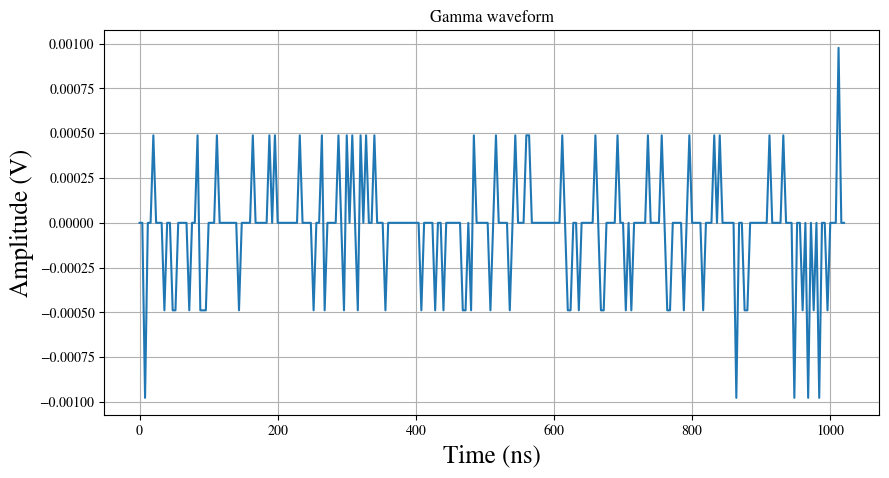

In [6]:
idc = 12000  
samples = 250*10**6
time = 1/samples * 1*10**(9)


time_axis = np.arange(record_length) * time
adc_levels = 2**12
vpp = 2.0
volts_per_count = vpp / adc_levels

pulse_volts = Pulses_corrected[idc].astype(np.float32) * volts_per_count

plt.figure(figsize=(10,5))
plt.plot(time_axis, pulse_volts)
plt.xlabel("Time (ns)", size=18)
plt.ylabel("Amplitude (V)", size=18)
plt.title("Gamma waveform")
plt.grid(True)
plt.show()

1352


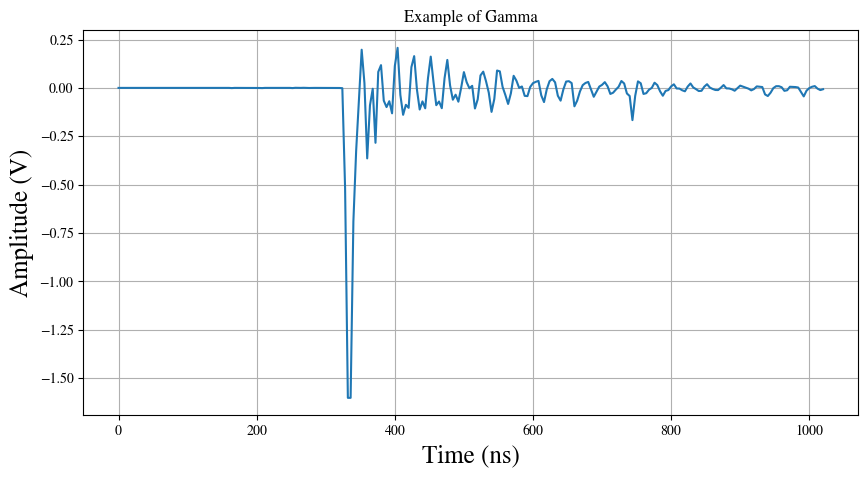

In [7]:
N = 200_000  
mins = Pulses_corrected[:N].min(axis=1)
idc = int(np.argmin(mins))
print(idc)

volts_per_count = 2.0 / (2**12)
pulse_volts = Pulses_corrected[idc].astype(np.float32) * volts_per_count

plt.figure(figsize=(10,5))
plt.plot(time_axis, pulse_volts)
plt.xlabel("Time (ns)", size=18)
plt.ylabel("Amplitude (V)", size=18)
plt.title('Example of Gamma')
plt.grid(True)
plt.show()

In [8]:
alpha_corr = r"D:\4th February data\Alphalongfeb_corrected_i16.bin"
record_length = 256

n_i16 = os.path.getsize(alpha_corr) // np.dtype(np.int16).itemsize
alpha_waveforms = n_i16 // record_length

Pulses_corrected_alpha = np.memmap(
    alpha_corr, dtype=np.int16, mode="r",
    shape=(alpha_waveforms, record_length)
)

print("alpha waveforms:", alpha_waveforms)

alpha waveforms: 7020849


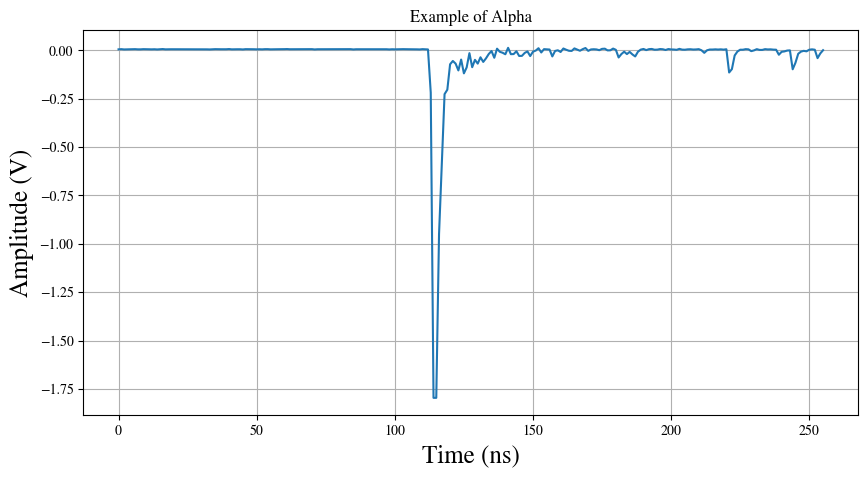

In [9]:
N = 200_000  
mins = Pulses_corrected_alpha[:N].min(axis=1)
idc_a = int(np.argmin(mins))


volts_per_count = 2.0 / (2**12)
pulse_volts_a = Pulses_corrected_alpha[idc_a].astype(np.float32) * volts_per_count

plt.figure(figsize=(10,5))
plt.plot( pulse_volts_a)
plt.xlabel("Time (ns)", size=18)
plt.ylabel("Amplitude (V)", size=18)
plt.title("Example of Alpha")
plt.grid(True)
plt.show()

## getting amplitudes

In [ ]:


def extract_amplitudes(pulse_volts, min_height=0.01, min_distance=50):
   
    peaks, properties = find_peaks(-pulse_volts, 
                                    height=min_height, 
                                    distance=min_distance)  
    return pulse_volts[peaks]  


gamma_amplitudes = []
for idc in range(len(Pulses_corrected)):
    pulse_volts = Pulses_corrected[idc].astype(np.float32) * volts_per_count
    gamma_amplitudes.append(np.min(pulse_volts)) 


alpha_amplitudes = []
for idc_a in range(len(Pulses_corrected_alpha)):
    pulse_volts_a = Pulses_corrected_alpha[idc_a].astype(np.float32) * volts_per_count
    alpha_amplitudes.append(np.min(pulse_volts_a))

gamma_amplitudes = np.array(gamma_amplitudes)
alpha_amplitudes = np.array(alpha_amplitudes)


# convert to volts

In [11]:
adc_levels = 2**12
vpp = 2.0
volts_per_count = vpp / adc_levels

chunk_wf = 50_000
amps_volts = []


for start in range(0, Pulses_corrected.shape[0], chunk_wf):
    stop = min(start + chunk_wf, Pulses_corrected.shape[0])

    
    mins_counts = np.min(Pulses_corrected[start:stop], axis=1)

    
    mins_volts = mins_counts.astype(np.float32) * volts_per_count

    amps_volts.append(mins_volts)

amps_volts = np.concatenate(amps_volts)

print("Amplitude array shape:", amps_volts.shape)
print("Example amplitudes (V):", amps_volts[:10])


Amplitude array shape: (7020849,)
Example amplitudes (V): [-0.00048828 -0.00097656 -0.00097656 -0.00097656 -0.00097656 -0.00097656
 -0.00146484 -0.00097656 -0.00048828 -0.00146484]


In [12]:
baseline_region = Pulses_corrected[:, :50]


baseline_volts = baseline_region * volts_per_count

sigma_noise = np.std(baseline_volts)

print("Noise sigma (V):", sigma_noise)

snr = np.abs(amps_volts) / sigma_noise

SNR_required = 4
amps_clean = amps_volts[snr > SNR_required]
print(snr)

Noise sigma (V): 0.001099705048021413
[0.4440111 0.8880222 0.8880222 ... 0.4440111 0.8880222 0.8880222]


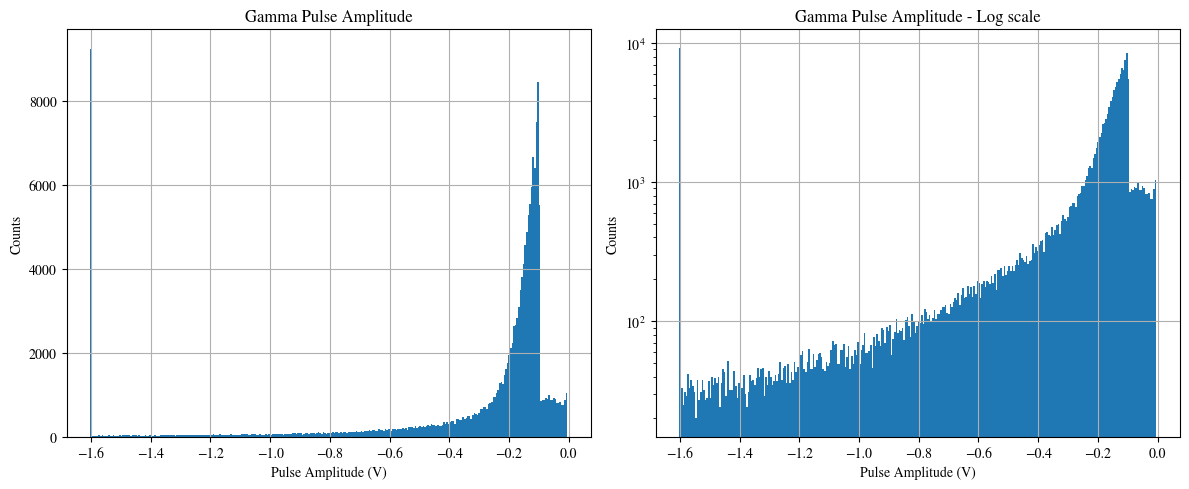

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(amps_clean, bins=300)
plt.xlabel("Pulse Amplitude (V)")
plt.ylabel("Counts")
plt.title("Gamma Pulse Amplitude")
plt.grid(True)

plt.subplot(1,2,2)
plt.hist(amps_clean, bins=300)
plt.xlabel("Pulse Amplitude (V)")
plt.ylabel("Counts")
plt.title("Gamma Pulse Amplitude - Log scale")
plt.yscale("log")
plt.grid(True)

plt.tight_layout()
plt.show()

In [14]:
alpha_corr = r"D:\4th February data\Alphalongfeb_corrected_i16.bin"
record_length = 256

n_i16 = os.path.getsize(alpha_corr) // np.dtype(np.int16).itemsize
alpha_waveforms = n_i16 // record_length

Pulses_corrected_alpha = np.memmap(
    alpha_corr, dtype=np.int16, mode="r",
    shape=(alpha_waveforms, record_length)
)

print("alpha waveforms:", alpha_waveforms)

alpha waveforms: 7020849


In [15]:
chunk_wf = 50_000
amps_alpha = []

for start in range(0, Pulses_corrected_alpha.shape[0], chunk_wf):
    stop = min(start + chunk_wf, Pulses_corrected_alpha.shape[0])

    mins_counts = np.min(Pulses_corrected_alpha[start:stop], axis=1)  # negative pulses
    mins_volts = mins_counts.astype(np.float32) * volts_per_count

    amps_alpha.append(mins_volts)

amps_alpha = np.concatenate(amps_alpha)

print("Alpha amplitude array shape:", amps_alpha.shape)



print("Example alpha amplitudes (V):", amps_alpha[:10])

Alpha amplitude array shape: (7020849,)
Example alpha amplitudes (V): [-0.11474609 -0.14746094 -0.11230469 -0.16601562 -0.85791016 -0.10400391
 -0.23095703 -0.16357422 -0.14794922 -0.85498047]


In [16]:
print("x shape:", amps_alpha.shape)
print("y shape:", amps_volts.shape)

x shape: (7020849,)
y shape: (7020849,)


Text(0.5, 1.0, '2D Scatter Plot')

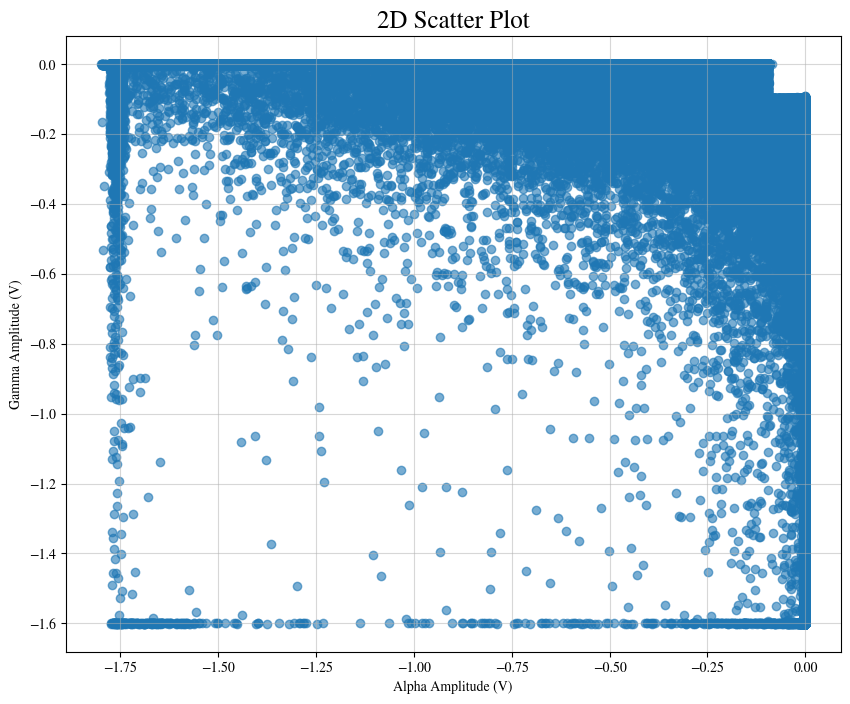

In [17]:
plt.figure(figsize=(10,8))

plt.scatter(amps_alpha, amps_volts, alpha=0.6)
plt.grid(alpha = 0.5)
plt.xlabel('Alpha Amplitude (V)')
plt.ylabel('Gamma Amplitude (V)')
plt.title('2D Scatter Plot', size = 18)

<Figure size 800x400 with 0 Axes>

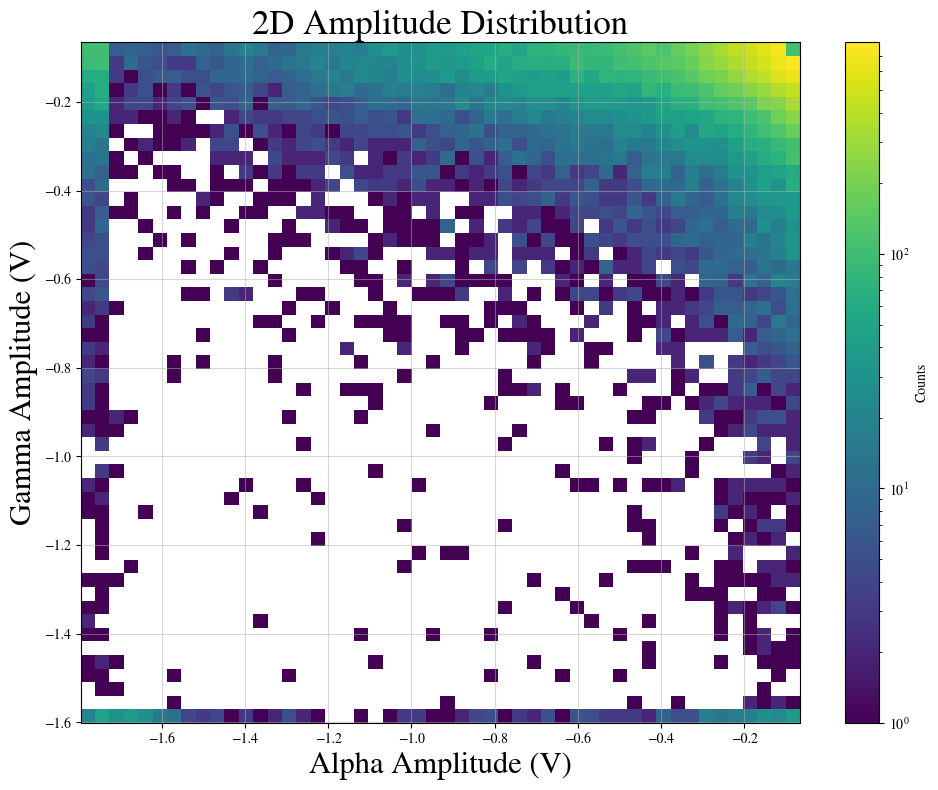

In [ ]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(8, 4))

mask = (amps_alpha < -0.065) & (amps_volts < -0.065)  

plt.figure(figsize=(10, 8))
plt.hist2d(amps_alpha[mask], amps_volts[mask], bins=50, norm='log', cmap='viridis')
plt.colorbar(label='Counts')
plt.grid(alpha=0.5)
plt.xlabel('Alpha Amplitude (V)', fontsize=22)
plt.ylabel('Gamma Amplitude (V)', fontsize=22)
plt.title('2D Amplitude Distribution', fontsize=25)
plt.tight_layout()
plt.show()

In [22]:
baseline_region2 = Pulses_corrected_alpha[:, :50]


baseline_volts2 = baseline_region2 * volts_per_count

sigma_noise2 = np.std(baseline_volts2)

print("Noise sigma (V):", sigma_noise2)

snr2 = np.abs(amps_alpha) / sigma_noise2

SNR_required = 4
amps_clean2 = amps_alpha[snr2 > SNR_required]


Noise sigma (V): 0.0042829699265140506


# GRAPHS FOR FINAL PROJECT/POSTER

## Baseline Subtraction

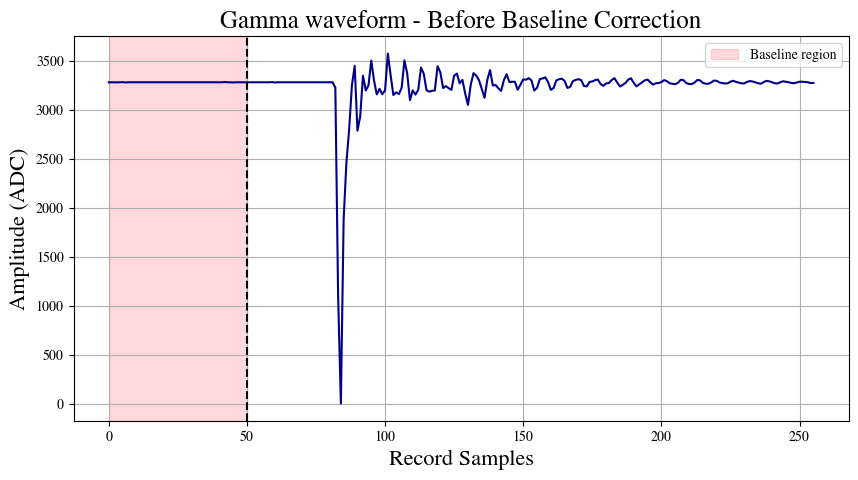

In [23]:
idc = 147142  
samples = 250*10**6
time = 1/samples * 1*10**(9)


time_axis = np.arange(record_length) * time
adc_levels = 2**12
vpp = 2.0
volts_per_count = vpp / adc_levels

pulse_volts = Pulses_corrected[idc].astype(np.float32) * volts_per_count

plt.figure(figsize=(10,5))
plt.plot( gamma_Pulses[idc], color = 'darkblue')
ax = plt.gca()

for spine in ax.spines.values():
    spine.set_visible(True)
plt.xlabel("Record Samples", size=16)
plt.ylabel("Amplitude (ADC)", size=16)
plt.axvline(50, linestyle = '--', color = 'black')
plt.axvspan(0, 50, color='red', alpha=0.15, label='Baseline region')
plt.title("Gamma waveform - Before Baseline Correction", size = 18)
plt.grid(True)
plt.legend()
plt.savefig('Baseline Before and After')
plt.show()

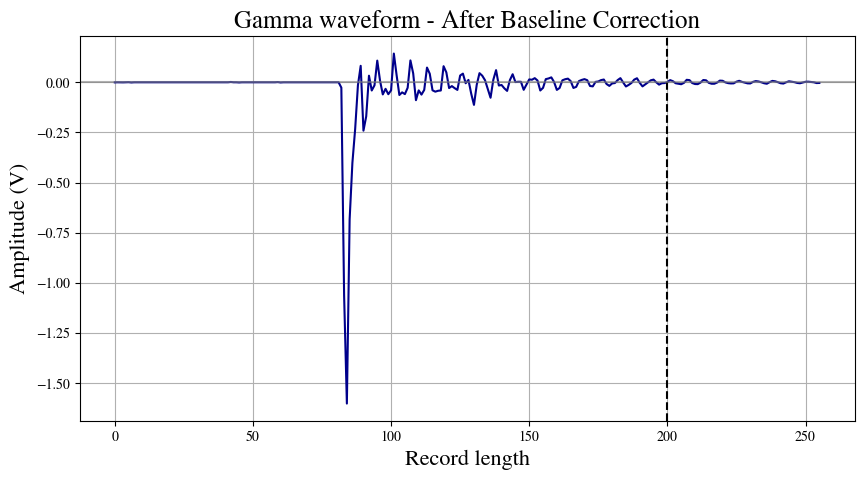

In [24]:
idc = 147142  

samples = 250e6
dt_ns = (1 / samples) * 1e9
time_axis = np.arange(record_length) * dt_ns

adc_levels = 2**12
vpp = 2.0
volts_per_count = vpp / adc_levels

pulse_volts = gamma_Pulses[idc].astype(np.float32) * volts_per_count

baseline = np.mean(pulse_volts[:50])

pulse_bs = pulse_volts - baseline


plt.figure(figsize=(10,5))
plt.plot( pulse_bs, color='darkblue')

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)

plt.xlabel("Record length", size=16)
plt.ylabel("Amplitude (V)", size=16)

plt.axvline(time_axis[50], linestyle='--', color='black')
plt.axhline(0, linestyle='-', color='grey', alpha=0.6)

plt.title("Gamma waveform - After Baseline Correction", size=18)

plt.grid(True)
plt.show()

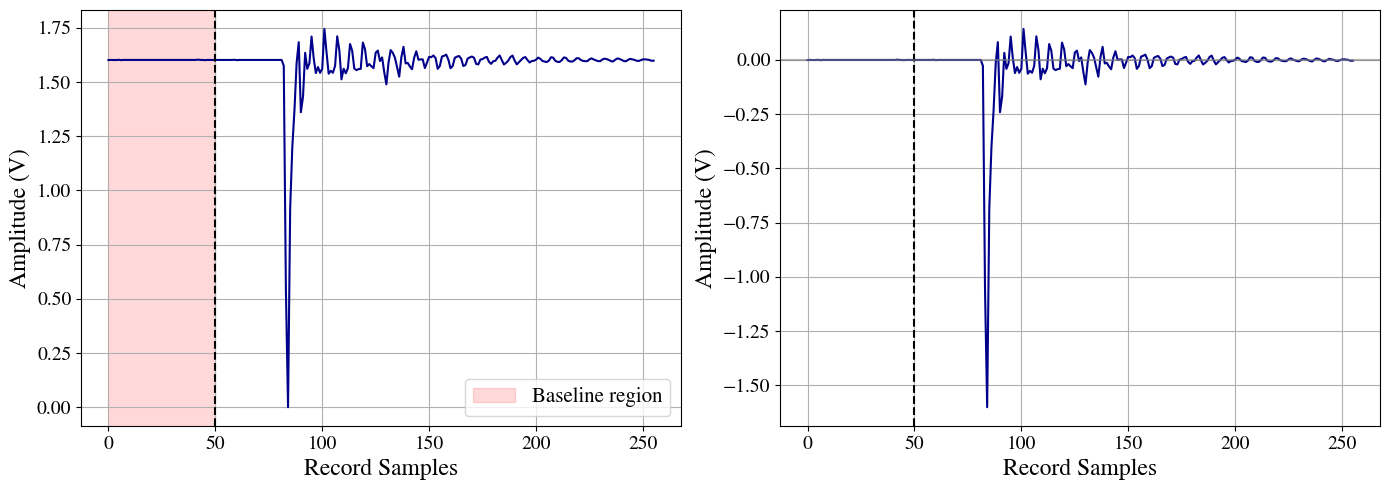

In [25]:
idc = 147142  

samples = 250e6
dt_ns = (1 / samples) * 1e9
time_axis = np.arange(record_length) * dt_ns


pulse_adc = gamma_Pulses[idc].astype(np.float32)


adc_levels = 2**12
vpp = 2.0
volts_per_count = vpp / adc_levels

pulse_volts = pulse_adc * volts_per_count

baseline = np.mean(pulse_volts[:50])
pulse_bs = pulse_volts - baseline

fig, axes = plt.subplots(1, 2, figsize=(14,5))


axes[0].plot(pulse_volts, color='darkblue')
axes[0].axvline(50, linestyle='--', color='black')
axes[0].axvspan(0, 50, color='red', alpha=0.15, label='Baseline region')
axes[0].set_xlabel("Record Samples", fontsize=17)
axes[0].set_ylabel("Amplitude (V)", fontsize=17)
axes[0].legend(fontsize=15)
axes[0].grid(True)

axes[1].plot(pulse_bs, color='darkblue')
axes[1].axvline(50, linestyle='--', color='black')
axes[1].axhline(0, color='grey', alpha=0.6)
axes[1].set_xlabel("Record Samples", fontsize=17)
axes[1].set_ylabel("Amplitude (V)", fontsize=17)
axes[1].grid(True)


for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)

for ax in axes:
    ax.tick_params(axis='both', labelsize=14)
    
plt.tight_layout()
plt.savefig('BAseline before and after')
plt.show()

# Pulse Amplitude Spectrums

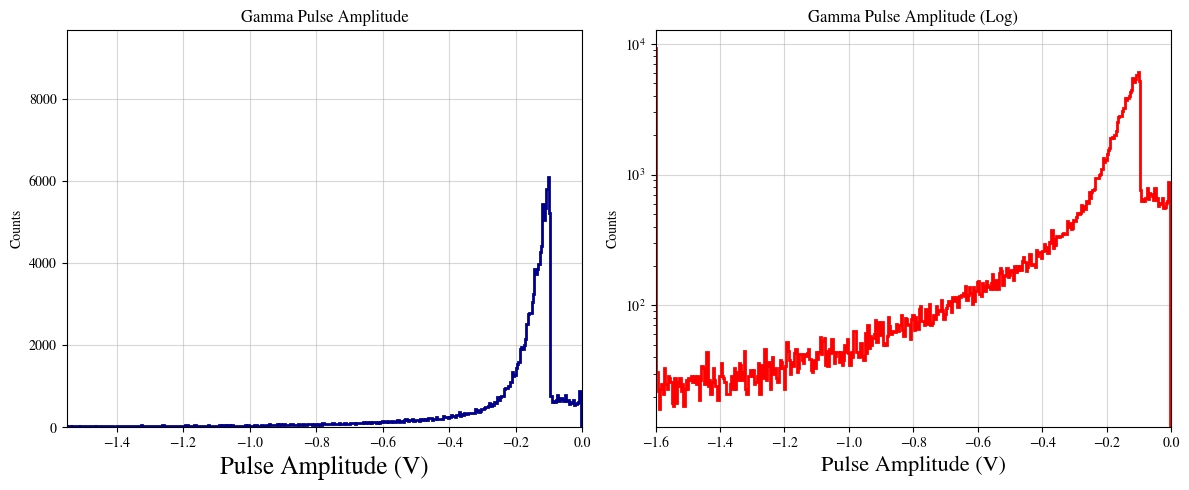

In [ ]:
plt.figure(figsize=(12,5))
for spine in ax.spines.values():
    spine.set_visible(True)

plt.subplot(1,2,1)
plt.hist(amps_clean, bins=400, histtype="step", linewidth=2, color='darkblue')
plt.xlabel("Pulse Amplitude (V)", size = 18)
for spine in ax.spines.values():
    spine.set_visible(True)
for ax in axes:
    ax.tick_params(axis='both', labelsize=14)
plt.ylabel("Counts")
plt.xlim(-1.55,0)
plt.title("Gamma Pulse Amplitude")
plt.grid(alpha=0.5)

plt.subplot(1,2,2)
plt.hist(amps_clean, bins=400, histtype="step", linewidth=2, color = 'red')
for spine in ax.spines.values():
    spine.set_visible(True)
plt.xlabel("Pulse Amplitude (V)", size = 16)
plt.ylabel("Counts")
plt.title("Gamma Pulse Amplitude (Log)")
plt.xlim(-1.6,0)
plt.yscale("log")
plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()

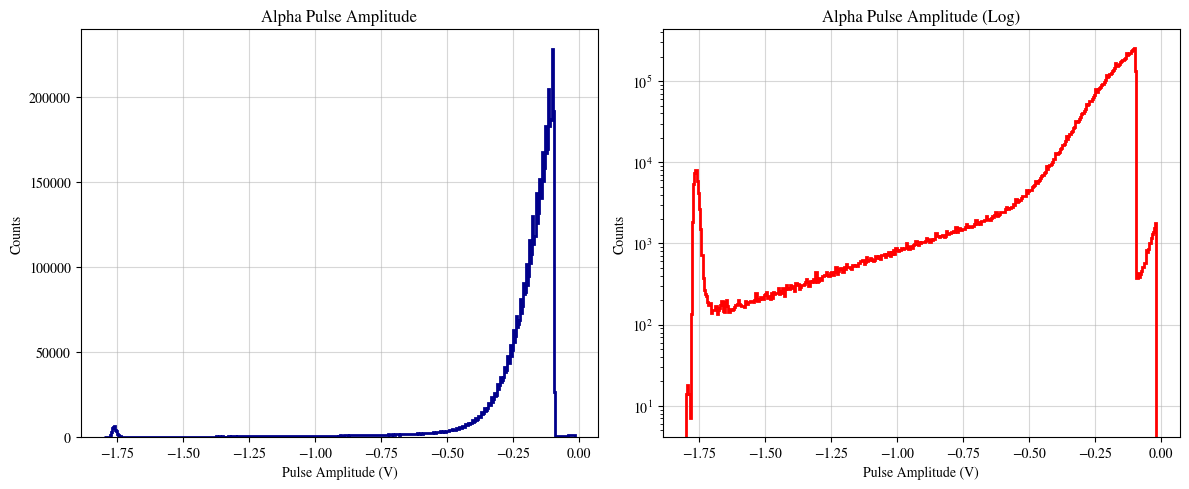

In [27]:


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(amps_clean2, bins=500, histtype="step", linewidth=2, color='darkblue')
plt.xlabel("Pulse Amplitude (V)")
plt.ylabel("Counts")
#plt.xlim(-1.8,-0.8)
plt.title("Alpha Pulse Amplitude")
plt.grid(alpha=0.5)

plt.subplot(1,2,2)
plt.hist(amps_clean2, bins=400, histtype="step", linewidth=2, color = 'red')
plt.xlabel("Pulse Amplitude (V)")
plt.ylabel("Counts")
plt.title("Alpha Pulse Amplitude (Log)")
#plt.xlim(-1.6,-0.5)
plt.yscale("log")
plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()

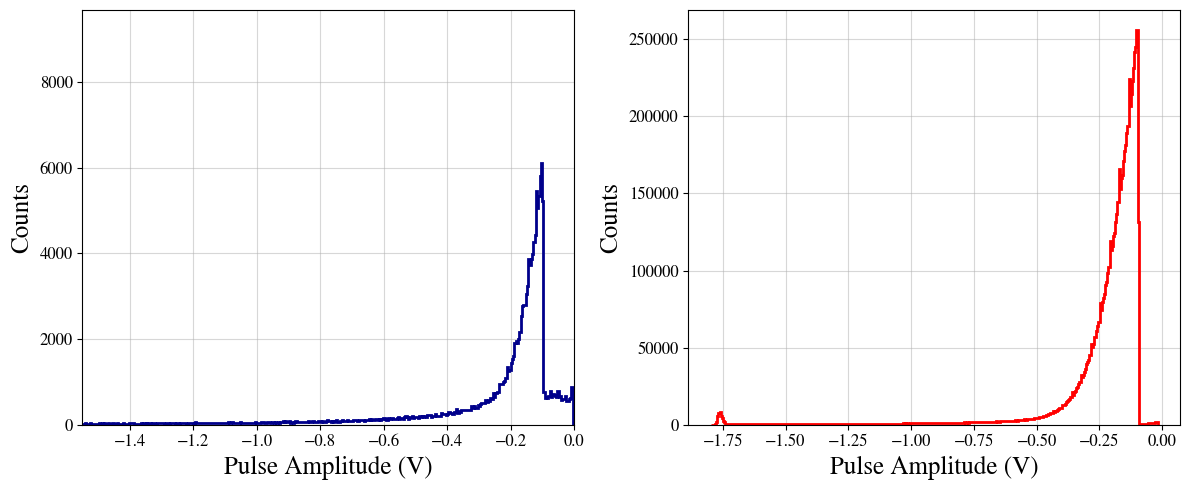

In [28]:
plt.figure(figsize=(12,5))
for spine in ax.spines.values():
    spine.set_visible(True)

plt.subplot(1,2,1)
plt.hist(amps_clean, bins=400, histtype="step", linewidth=2, color='darkblue')
plt.xlabel("Pulse Amplitude (V)", size = 18)
for spine in ax.spines.values():
    spine.set_visible(True)
plt.ylabel("Counts", size = 18)
plt.xlim(-1.55,0)
#plt.title("Gamma Pulse Amplitude Spectrum", fontsize = 20)
plt.grid(alpha=0.5)
plt.tick_params(axis='both', labelsize=12)

plt.subplot(1,2,2)
plt.hist(amps_clean2, bins=400, histtype="step", linewidth=2, color = 'red')
for spine in ax.spines.values():
    spine.set_visible(True)
plt.xlabel("Pulse Amplitude (V)", size = 18)
plt.ylabel("Counts", size = 18)
#plt.title("Alpha Pulse Amplitude Spectrum", size = 20)
#plt.xlim(-1.6,0)
#plt.yscale("log")
plt.grid(alpha=0.5)
plt.tick_params(axis='both', labelsize=12)


plt.tight_layout()
plt.savefig('PulseAmps')
plt.show()

## SIMPLE TIMING METHOD

In [29]:
#using linear interpolation for all timing methods to get a more accurate time mark

def simple_min_timing_linear(waveforms, amp_threshold, chunk_size=50000):
    N, L = waveforms.shape
    times = np.full(N, np.nan, dtype=np.float32)

    for start in range(0, N, chunk_size):
        end = min(start + chunk_size, N)
        chunk = waveforms[start:end].astype(np.float32)

        amp = chunk.min(axis=1)
        real_pulses = np.where(amp < amp_threshold)[0]

        for i in real_pulses:
            pulse = chunk[i]
            k = int(np.argmin(pulse))

            if 0 < k < L - 1:
                y_prev = pulse[k-1]
                y_next = pulse[k+1]
                delta = 0.5 * (y_prev - y_next) / (y_prev + y_next - 2*pulse[k])
                times[start + i] = k + delta
            else:
                times[start + i] = k

        if start % 500000 == 0:
            print(f"  {start}/{N} waveforms processed...")

    return times


alpha_times_simple = simple_min_timing_linear(Pulses_corrected_alpha, amp_threshold=-100)
gamma_times_simple = simple_min_timing_linear(Pulses_corrected,       amp_threshold=-100)

dt_simple = (gamma_times_simple - alpha_times_simple) * 4  

alpha_amps = Pulses_corrected_alpha.min(axis=1) * volts_per_count
gamma_amps = Pulses_corrected.min(axis=1) * volts_per_count

valid_mask = ~np.isnan(dt_simple)
coinc_mask = valid_mask & \
             (dt_simple > -550) & (dt_simple < 850) & \
             (alpha_amps > -1.74) & \
             (gamma_amps > -1.54)

dt_coinc_simple = dt_simple[coinc_mask]
print("Coincidences", len(dt_coinc_simple))
print(f"Valid coincidences: {valid_mask.sum()}")

  0/7020849 waveforms processed...
  500000/7020849 waveforms processed...
  1000000/7020849 waveforms processed...
  1500000/7020849 waveforms processed...
  2000000/7020849 waveforms processed...
  2500000/7020849 waveforms processed...
  3000000/7020849 waveforms processed...
  3500000/7020849 waveforms processed...
  4000000/7020849 waveforms processed...
  4500000/7020849 waveforms processed...
  5000000/7020849 waveforms processed...
  5500000/7020849 waveforms processed...
  6000000/7020849 waveforms processed...
  6500000/7020849 waveforms processed...
  7000000/7020849 waveforms processed...
  0/7020849 waveforms processed...
  500000/7020849 waveforms processed...
  1000000/7020849 waveforms processed...
  1500000/7020849 waveforms processed...
  2000000/7020849 waveforms processed...
  2500000/7020849 waveforms processed...
  3000000/7020849 waveforms processed...
  3500000/7020849 waveforms processed...
  4000000/7020849 waveforms processed...
  4500000/7020849 waveforms pr

  0/7020849 waveforms processed...
  500000/7020849 waveforms processed...
  1000000/7020849 waveforms processed...
  1500000/7020849 waveforms processed...
  2000000/7020849 waveforms processed...
  2500000/7020849 waveforms processed...
  3000000/7020849 waveforms processed...
  3500000/7020849 waveforms processed...
  4000000/7020849 waveforms processed...
  4500000/7020849 waveforms processed...
  5000000/7020849 waveforms processed...
  5500000/7020849 waveforms processed...
  6000000/7020849 waveforms processed...
  6500000/7020849 waveforms processed...
  7000000/7020849 waveforms processed...
  0/7020849 waveforms processed...
  500000/7020849 waveforms processed...
  1000000/7020849 waveforms processed...
  1500000/7020849 waveforms processed...
  2000000/7020849 waveforms processed...
  2500000/7020849 waveforms processed...
  3000000/7020849 waveforms processed...
  3500000/7020849 waveforms processed...
  4000000/7020849 waveforms processed...
  4500000/7020849 waveforms pr

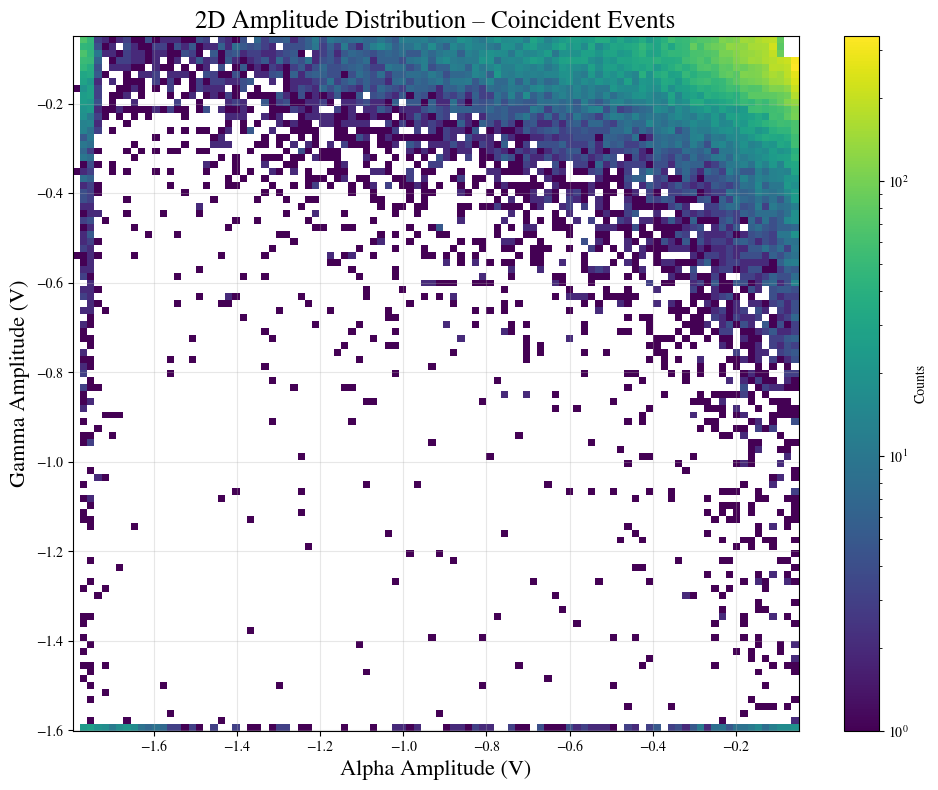

In [30]:

alpha_times_simple = simple_min_timing_linear(Pulses_corrected_alpha, amp_threshold=-100)
gamma_times_simple = simple_min_timing_linear(Pulses_corrected,       amp_threshold=-100)

dt_simple = (gamma_times_simple - alpha_times_simple) * 4 

valid_mask = ~np.isnan(dt_simple)
coinc_mask = valid_mask & (dt_simple > -550) & (dt_simple < 850)

dt_coinc_simple = dt_simple[coinc_mask]
print("Coincidences:", len(dt_coinc_simple))

alpha_amps_coinc = Pulses_corrected_alpha[coinc_mask].min(axis=1) * volts_per_count
gamma_amps_coinc = Pulses_corrected[coinc_mask].min(axis=1) * volts_per_count

plt.figure(figsize=(10,8))
plt.hist2d(alpha_amps_coinc, gamma_amps_coinc, bins=100, norm='log', cmap='viridis')
plt.colorbar(label='Counts')
plt.xlabel('Alpha Amplitude (V)', fontsize=16)
plt.ylabel('Gamma Amplitude (V)', fontsize=16)
plt.title('2D Amplitude Distribution – Coincident Events', fontsize=18)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

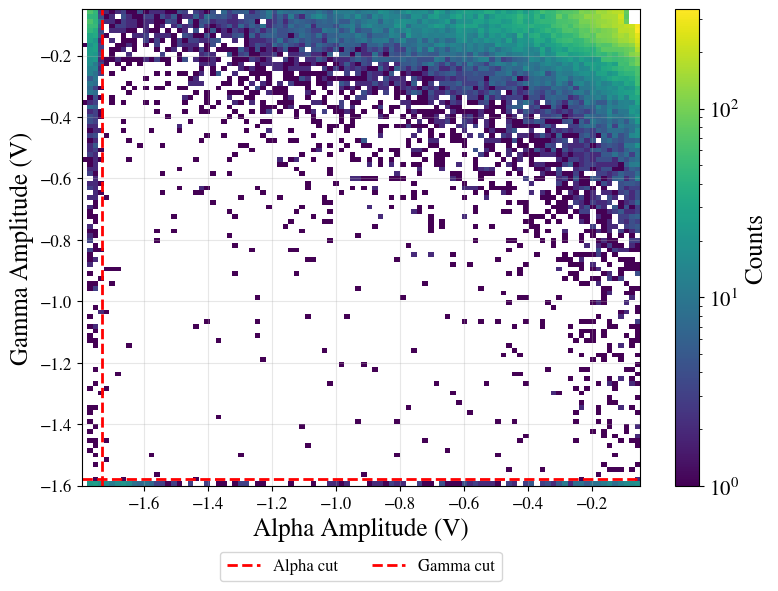

In [31]:

plt.figure(figsize=(8,6))
plt.hist2d(alpha_amps_coinc, gamma_amps_coinc, bins=100, norm='log', cmap='viridis')
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=18)
cbar.ax.tick_params(labelsize=15)
plt.xlabel('Alpha Amplitude (V)', fontsize=18)
plt.ylabel('Gamma Amplitude (V)', fontsize=18)
#plt.title('2D Amplitude Distribution', fontsize=22)
plt.tick_params(labelsize=12)
plt.axvline(-1.73, color='red', lw=2, linestyle='--', label='Alpha cut')
plt.axhline(-1.58, color='red', lw=2, linestyle='--', label='Gamma cut')
plt.legend(fontsize=12, bbox_to_anchor=(0.5, -0.12), loc='upper center', ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('2dHIST')
plt.show()

## LEADING EDGE

In [32]:

def leading_edge_timing_linear(waveforms, threshold, interpolate=True, chunk_size=50000):
    N, L = waveforms.shape
    times = np.full(N, np.nan, dtype=np.float32)

    for start in range(0, N, chunk_size):
        end = min(start + chunk_size, N)
        chunk = waveforms[start:end].astype(np.float32)

        below = chunk < threshold
        any_crossed = below.any(axis=1)
        first_cross = np.argmax(below, axis=1)

        t = first_cross.astype(np.float32)

        if interpolate:
            valid = (first_cross > 0) & any_crossed
            idx = first_cross[valid]
            rows = np.where(valid)[0]
            y0 = chunk[rows, idx - 1]
            y1 = chunk[rows, idx]
            frac = (threshold - y0) / (y1 - y0)
            t[rows] = (idx - 1) + frac

        t[~any_crossed] = np.nan
        times[start:end] = t

        if start % 500000 == 0:
            print(f"  {start}/{N} waveforms processed...")

    return times


alpha_min = Pulses_corrected_alpha.min(axis=1)
gamma_min = Pulses_corrected.min(axis=1)

alpha_amps_v = alpha_min * volts_per_count
gamma_amps_v = gamma_min * volts_per_count

alpha_trig = (alpha_min < -100) & (alpha_amps_v > -1.74)
gamma_trig = (gamma_min < -100) & (gamma_amps_v > -1.54)

both = alpha_trig & gamma_trig

print("Alpha triggers:", alpha_trig.mean())
print("Gamma triggers:", gamma_trig.mean())
print("Both triggers :", both.mean(), "  N =", both.sum())


alpha_times = leading_edge_timing_linear(
    Pulses_corrected_alpha[both],
    threshold=-100
)

gamma_times = leading_edge_timing_linear(
    Pulses_corrected[both],
    threshold=-100
)

dt = (gamma_times - alpha_times) * 4
dt_clean = dt[np.isfinite(dt)]
dt_coinc_LED = dt_clean[(dt_clean > -450) & (dt_clean < 550)]
print("LED coincidences:", len(dt_coinc_LED))
print("Valid dt:", len(dt_clean))



Alpha triggers: 0.9770859621108501
Gamma triggers: 0.020846196806112764
Both triggers : 0.0043518953334561105   N = 30554
  0/30554 waveforms processed...
  0/30554 waveforms processed...
LED coincidences: 29729
Valid dt: 30554


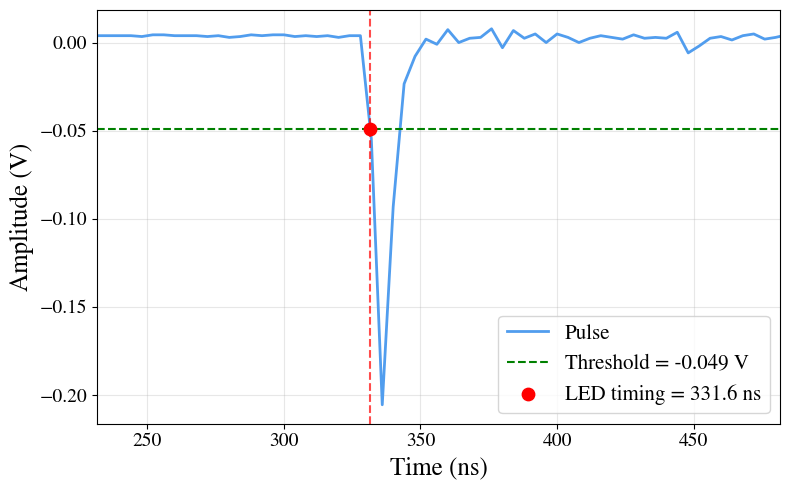

In [33]:

threshold_v = -100 * volts_per_count  

example_idx = np.where(both)[0][1]
pulse = Pulses_corrected_alpha[example_idx].astype(np.float32) * volts_per_count
time_axis = np.arange(len(pulse)) * 4  


below = pulse < threshold_v
first_cross = np.argmax(below)
y0 = pulse[first_cross - 1]
y1 = pulse[first_cross]
frac = (threshold_v - y0) / (y1 - y0)
t_led = (first_cross - 1 + frac) * 4  

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(time_axis, pulse, color='#519DEE', lw=2, label='Pulse')
ax.axhline(threshold_v, color='green', linestyle='--', lw=1.5, 
           label=f'Threshold = {threshold_v:.3f} V')
ax.scatter([t_led], [threshold_v], color='red', zorder=5, s=80,
           label=f'LED timing = {t_led:.1f} ns')
ax.axvline(t_led, color='red', linestyle='--', lw=1.5, alpha=0.7)
ax.set_xlabel('Time (ns)', fontsize=18)
ax.set_ylabel('Amplitude (V)', fontsize=18)
#ax.set_title('LED Timing – Time Extraction', fontsize=20)
ax.legend(fontsize=15)
ax.tick_params(axis='both', labelsize=14)
ax.grid(alpha=0.3)
ax.set_xlim(t_led - 100, t_led + 150)
plt.tight_layout()
plt.savefig('led_timing_example')
plt.show()



In [35]:
def cfd_timing(waveforms, fraction=0.35, delay_samples=3,
               amp_threshold=-100, chunk_size=50000):
    N, L = waveforms.shape
    times = np.full(N, np.nan, dtype=np.float32)

    for start in range(0, N, chunk_size):
        end = min(start + chunk_size, N)
        chunk = waveforms[start:end].astype(np.float32)

        amp = chunk.min(axis=1)
        real_pulse = np.where(amp < amp_threshold)[0]

        for i in real_pulse:
            pulse = chunk[i]
            attenuated = fraction * pulse
            delayed = np.zeros_like(pulse)
            delayed[delay_samples:] = pulse[:-delay_samples]
            cfd_sig = attenuated - delayed

            peak_idx = np.argmin(pulse)
            search = cfd_sig[peak_idx:]
            cross = np.where((search[:-1] <= 0) & (search[1:] > 0))[0]

            if len(cross) == 0:
                continue

            idx = cross[0] + peak_idx
            if idx + 1 < L:
                y0, y1 = cfd_sig[idx], cfd_sig[idx + 1]
                if y1 != y0:
                    times[start + i] = idx + (-y0 / (y1 - y0))

        if start % 500000 == 0:
            print(f"  {start}/{N} waveforms processed...")

    return times


alpha_times_cfd = cfd_timing(Pulses_corrected_alpha, fraction=0.3,
                              delay_samples=5, amp_threshold=-100)
gamma_times_cfd = cfd_timing(Pulses_corrected, fraction=0.3,
                              delay_samples=5, amp_threshold=-100)

dt_cfd = (gamma_times_cfd - alpha_times_cfd) * 4

alpha_amps_v = Pulses_corrected_alpha.min(axis=1) * volts_per_count
gamma_amps_v = Pulses_corrected.min(axis=1) * volts_per_count

valid_mask = ~np.isnan(dt_cfd)
coinc_mask = valid_mask & \
             (dt_cfd > -450) & (dt_cfd < 850) & \
             (alpha_amps_v > -1.74) & \
             (gamma_amps_v > -1.54)

dt_coinc_CFD = dt_cfd[coinc_mask]


print(f"CFD coincidences after amplitude cuts: {len(dt_coinc_CFD)}")

  0/7020849 waveforms processed...
  500000/7020849 waveforms processed...
  1000000/7020849 waveforms processed...
  1500000/7020849 waveforms processed...
  2000000/7020849 waveforms processed...
  2500000/7020849 waveforms processed...
  3000000/7020849 waveforms processed...
  3500000/7020849 waveforms processed...
  4000000/7020849 waveforms processed...
  4500000/7020849 waveforms processed...
  5000000/7020849 waveforms processed...
  5500000/7020849 waveforms processed...
  6000000/7020849 waveforms processed...
  6500000/7020849 waveforms processed...
  7000000/7020849 waveforms processed...
  0/7020849 waveforms processed...
  500000/7020849 waveforms processed...
  1000000/7020849 waveforms processed...
  1500000/7020849 waveforms processed...
  2000000/7020849 waveforms processed...
  2500000/7020849 waveforms processed...
  3000000/7020849 waveforms processed...
  3500000/7020849 waveforms processed...
  4000000/7020849 waveforms processed...
  4500000/7020849 waveforms pr

# FINAL GRAPHS 

meeting: pass sigma through twice

estimate background from region before to test if it matches background fitted param
dont fix background, have background as a free param

Initial background estimate B = 17.05 ± 0.48 counts/bin

Simple timing fit results
  Mean lifetime   = 100.31 ± 2.60 ns
  Halflife  T1/2  = 69.53 ± 1.80 ns
  B     = 19.60 ± 3.76 counts/bin (fitted)
  chisquared          = 1.22


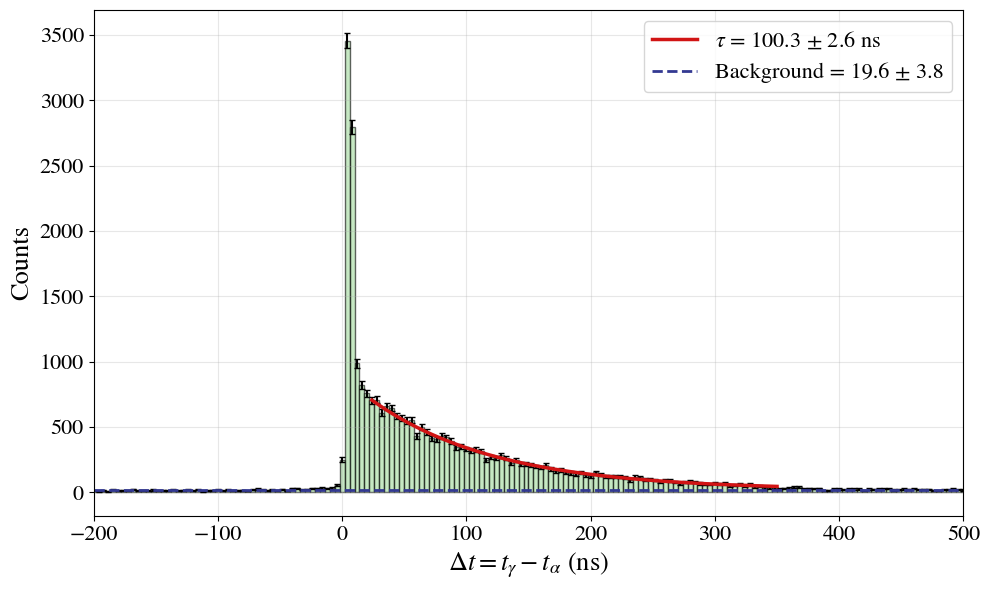

In [36]:
window_ns = 1200
bin_width = 4
dt_step_ns = bin_width

counts, bin_edges = np.histogram(
    dt_coinc_simple,
    bins=np.arange(-450, 850 + bin_width, bin_width)
)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

bg_mask = (bin_centres < -20) & (bin_centres > -400)
B_init = counts[bg_mask].mean()
B_init_err = counts[bg_mask].std() / np.sqrt(bg_mask.sum())
print(f"Initial background estimate B = {B_init:.2f} ± {B_init_err:.2f} counts/bin")

def exp_free_bg_simple(t, A, tau, B):
    return A * np.exp(-t / tau) + B

t_min_fit = 24
t_max_fit = 350

fit_mask = (bin_centres >= t_min_fit) & (bin_centres <= t_max_fit) & (counts > 0)

x_fit = bin_centres[fit_mask]
y_fit = counts[fit_mask].astype(float)
sigma_fit = np.sqrt(np.maximum(y_fit, 1.0))

A0 = y_fit.max()
tau0 = 100.0

popt, pcov = curve_fit(
    exp_free_bg_simple,
    x_fit, y_fit,
    p0=[A0, tau0, B_init],
    sigma=sigma_fit, absolute_sigma=True,
    bounds=([0, 1e-6, 0], [np.inf, np.inf, np.inf]),
    maxfev=200000
)

sigma_fit2 = np.sqrt(np.maximum(exp_free_bg_simple(x_fit, *popt), 1.0))
popt, pcov = curve_fit(
    exp_free_bg_simple,
    x_fit, y_fit,
    p0=popt,
    sigma=sigma_fit2, absolute_sigma=True,
    bounds=([0, 1e-6, 0], [np.inf, np.inf, np.inf]),
    maxfev=200000
)

A_fit, tau_fit, B_fit = popt
A_err, tau_err, B_err = np.sqrt(np.diag(pcov))

y_model = exp_free_bg_simple(x_fit, *popt)
chi2 = np.sum(((y_fit - y_model) / sigma_fit2) ** 2)
dof = len(x_fit) - 3
chi2_dof = chi2 / dof if dof > 0 else np.nan

T12 = tau_fit * np.log(2)
T12_err = tau_err * np.log(2)

print("\nSimple timing fit results")
print(f"  Mean lifetime   = {tau_fit:.2f} ± {tau_err:.2f} ns")
print(f"  Halflife  T1/2  = {T12:.2f} ± {T12_err:.2f} ns")
print(f"  B     = {B_fit:.2f} ± {B_err:.2f} counts/bin (fitted)")
print(f"  chisquared          = {chi2_dof:.2f}")


t_plot = np.linspace(t_min_fit, t_max_fit, 800)

fig, ax = plt.subplots(figsize=(10, 6))

plot_mask = bin_centres >= -450

ax.bar(
    bin_edges[:-1][plot_mask], counts[plot_mask],
    width=dt_step_ns, align='edge',
    alpha=0.6, edgecolor='black', color='#a1d99b'
)
ax.errorbar(
    bin_centres[plot_mask], counts[plot_mask],
    yerr=np.sqrt(np.maximum(counts[plot_mask].astype(float), 1.0)),
    fmt='none', ecolor='black', capsize=2
)
ax.plot(
    t_plot, exp_free_bg_simple(t_plot, *popt),
    linewidth=2.5, color="#d11414",
    label=rf"$\tau$ = {tau_fit:.1f} ± {tau_err:.1f} ns"
)
ax.axhline(B_fit, color="#333992", linewidth=2, linestyle='--',
           label=f'Background = {B_fit:.1f} ± {B_err:.1f}')

ax.set_xlim(-200, 500)
ax.set_xlabel(r'$\Delta t = t_\gamma - t_\alpha$ (ns)', fontsize=19)
ax.set_ylabel('Counts', fontsize=19)
ax.tick_params(axis='both', labelsize=16)
#ax.set_title('Simple Timing – Lifetime Fit', fontsize=22)
ax.legend(fontsize=16)
ax.grid(alpha=0.3)


plt.tight_layout()
plt.savefig('SimpleReport')
plt.show()



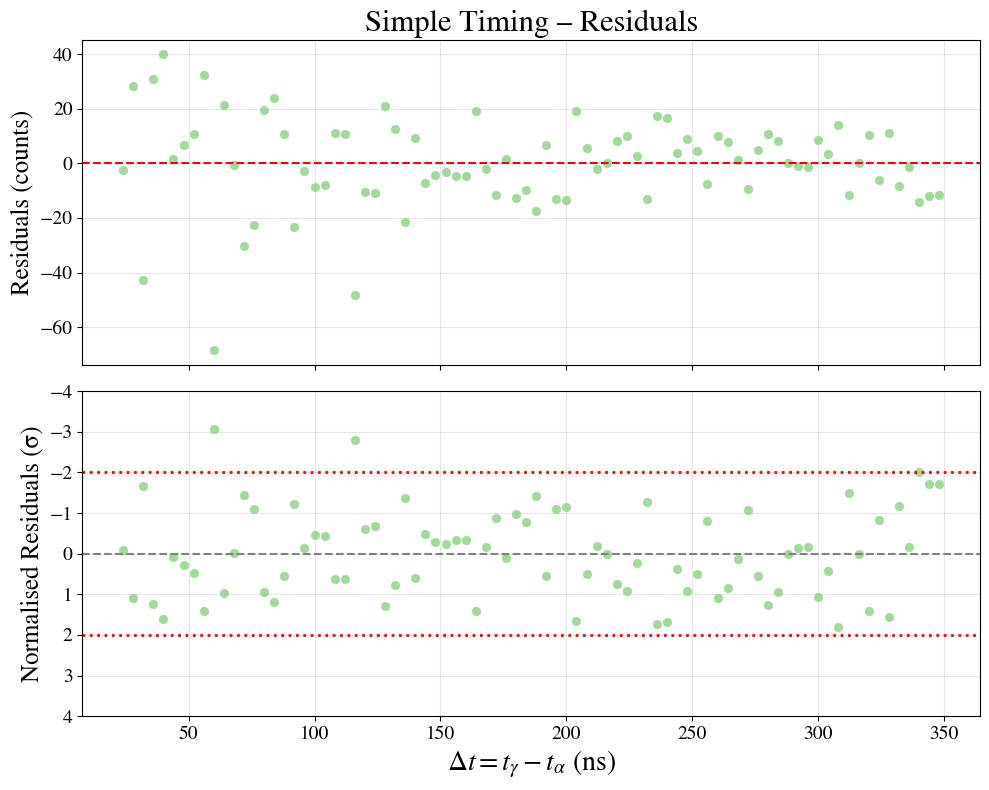

In [37]:

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

fit_mask_res = (bin_centres >= t_min_fit) & (bin_centres <= t_max_fit) & (counts > 0)
x_res = bin_centres[fit_mask_res]
y_res = counts[fit_mask_res].astype(float)
y_model_res = exp_free_bg_simple(x_res, *popt)
sigma_res = np.sqrt(np.maximum(y_model_res, 1.0))
residuals = y_res - y_model_res
norm_residuals = residuals / sigma_res

ax1.scatter(x_res, residuals, color='#a1d99b', s=40, marker = 'o', linewidths=0.3)
ax1.axhline(0, color='red', lw=1.5, linestyle='--')
ax1.set_ylabel('Residuals (counts)', fontsize=18)
ax1.set_title('Simple Timing – Residuals', fontsize=22)
ax1.tick_params(axis='both', labelsize=14)
ax1.grid(alpha=0.3)

ax2.scatter(x_res, norm_residuals, color='#a1d99b', s=40,  marker = 'o', linewidths=0.3)
ax2.axhline(0,  color='grey',  lw=1.5, linestyle='--')
ax2.axhline(2,  color='red', lw=2,   linestyle=':')
ax2.axhline(-2, color='red', lw=2,   linestyle=':')
ax2.set_xlabel(r'$\Delta t = t_\gamma - t_\alpha$ (ns)', fontsize=20)
plt.ylim(4,-4)
ax2.set_ylabel('Normalised Residuals (σ)', fontsize=18)
ax2.tick_params(axis='both', labelsize=14)
ax2.grid(alpha=0.3)


plt.tight_layout()
plt.savefig('Simple_residuals')
plt.show()

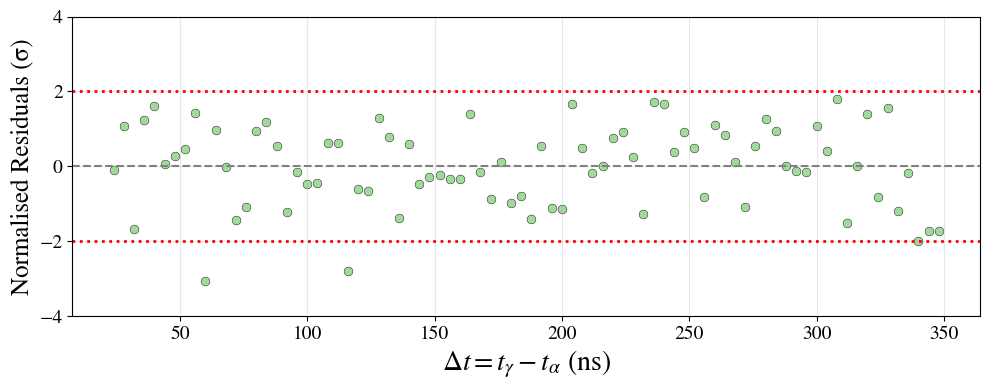

In [38]:
fig, ax = plt.subplots(figsize=(10, 4))

fit_mask_res = (bin_centres >= t_min_fit) & (bin_centres <= t_max_fit) & (counts > 0)
x_res = bin_centres[fit_mask_res]
y_res = counts[fit_mask_res].astype(float)
y_model_res = exp_free_bg_simple(x_res, *popt)
sigma_res = np.sqrt(np.maximum(y_model_res, 1.0))
residuals = y_res - y_model_res
norm_residuals = residuals / sigma_res

ax.scatter(x_res, norm_residuals, color='#a1d99b', s=40, marker='o',
           edgecolors='black', linewidths=0.3)
ax.axhline(0,  color='grey', lw=1.5, linestyle='--')
ax.axhline(2,  color='red',  lw=2,   linestyle=':')
ax.axhline(-2, color='red',  lw=2,   linestyle=':')
ax.set_xlabel(r'$\Delta t = t_\gamma - t_\alpha$ (ns)', fontsize=20)
ax.set_ylabel('Normalised Residuals (σ)', fontsize=18)
#ax.set_title('Simple Timing – Normalised Residuals', fontsize=20)
ax.set_ylim(-4, 4)
ax.tick_params(axis='both', labelsize=14)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Simple_residuals')
plt.show()

# LED Final 

Initial background estimate B = 13.22 ± 0.57 counts/bin

LED timing fit results
  Mean lifetime   = 99.54 ± 2.66 ns
  Halflife  = 69.00 ± 1.84 ns
  B     = 14.51 ± 3.79 counts/bin (fitted)
  chisquared         = 0.96


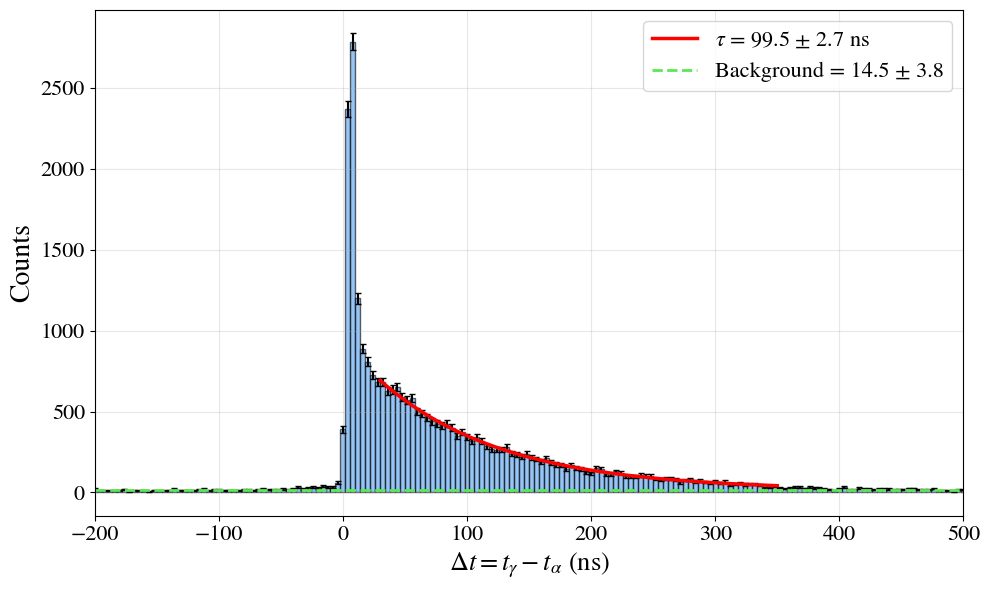

In [39]:
window_ns = 850
bin_width = 4
dt_step_ns = bin_width

counts, bin_edges = np.histogram(
    dt_coinc_LED,
    bins=np.arange(-450, 850 + bin_width, bin_width)
)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

bg_mask = (bin_centres < -20) & (bin_centres > -400)
B_init = counts[bg_mask].mean()
B_init_err = counts[bg_mask].std() / np.sqrt(bg_mask.sum())
print(f"Initial background estimate B = {B_init:.2f} ± {B_init_err:.2f} counts/bin")

def exp_free_bg_led(t, A, tau, B):
    return A * np.exp(-t / tau) + B

t_min_fit = 30
t_max_fit = 350

fit_mask = (bin_centres >= t_min_fit) & (bin_centres <= t_max_fit) & (counts > 0)

x_fit = bin_centres[fit_mask]
y_fit = counts[fit_mask].astype(float)
sigma_fit = np.sqrt(np.maximum(y_fit, 1.0))

A0 = y_fit.max()
tau0 = 100.0

popt, pcov = curve_fit(
    exp_free_bg_led,
    x_fit, y_fit,
    p0=[A0, tau0, B_init],
    sigma=sigma_fit, absolute_sigma=True,
    bounds=([0, 1e-6, 0], [np.inf, np.inf, np.inf]),
    maxfev=200000
)

sigma_fit2 = np.sqrt(np.maximum(exp_free_bg_led(x_fit, *popt), 1.0))
popt, pcov = curve_fit(
    exp_free_bg_led,
    x_fit, y_fit,
    p0=popt,
    sigma=sigma_fit2, absolute_sigma=True,
    bounds=([0, 1e-6, 0], [np.inf, np.inf, np.inf]),
    maxfev=200000
)

A_fit, tau_fit, B_fit = popt
A_err, tau_err, B_err = np.sqrt(np.diag(pcov))

y_model = exp_free_bg_led(x_fit, *popt)
chi2 = np.sum(((y_fit - y_model) / sigma_fit2) ** 2)
dof = len(x_fit) - 3
chi2_dof = chi2 / dof if dof > 0 else np.nan

T12 = tau_fit * np.log(2)
T12_err = tau_err * np.log(2)

print("\nLED timing fit results")
print(f"  Mean lifetime   = {tau_fit:.2f} ± {tau_err:.2f} ns")
print(f"  Halflife  = {T12:.2f} ± {T12_err:.2f} ns")
print(f"  B     = {B_fit:.2f} ± {B_err:.2f} counts/bin (fitted)")
print(f"  chisquared         = {chi2_dof:.2f}")


t_plot = np.linspace(t_min_fit, t_max_fit, 600)

fig, ax = plt.subplots(figsize=(10, 6))

plot_mask = bin_centres >= -450

ax.bar(
    bin_edges[:-1][plot_mask], counts[plot_mask],
    width=dt_step_ns, align='edge',
    alpha=0.6, edgecolor='black', color="#519DEE"
)
ax.errorbar(
    bin_centres[plot_mask], counts[plot_mask],
    yerr=np.sqrt(np.maximum(counts[plot_mask].astype(float), 1.0)),
    fmt='none', ecolor='black', capsize=2
)
ax.plot(
    t_plot, exp_free_bg_led(t_plot, *popt),
    'r', lw=2.5,
    label=rf"$\tau$ = {tau_fit:.1f} ± {tau_err:.1f} ns"
)
ax.axhline(B_fit, color="#59E857", linewidth=2, linestyle='--',
           label=f'Background = {B_fit:.1f} ± {B_err:.1f}')

ax.set_xlim(-200, 500)
ax.set_xlabel(r'$\Delta t = t_\gamma - t_\alpha$ (ns)', fontsize=19)
ax.set_ylabel('Counts', fontsize=20)
ax.tick_params(axis='both', labelsize=16)
#ax.set_title('LED Timing – Lifetime Fit', fontsize=22)
ax.legend(fontsize=16)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('LEDReport')
plt.show()

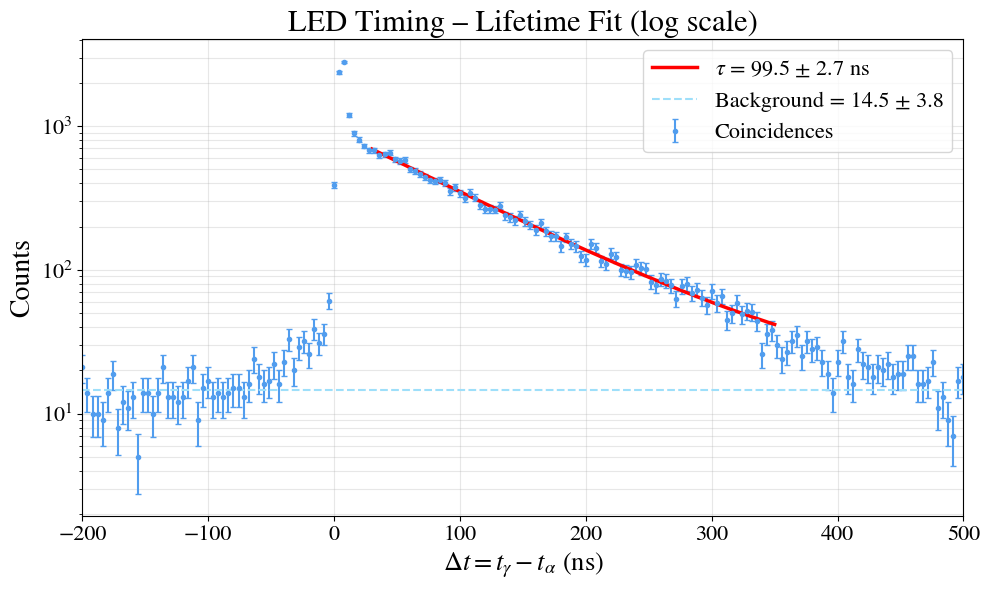

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

plot_mask = (bin_centres >= -200) & (bin_centres <= 500) & (counts > 0)

ax.errorbar(
    bin_centres[plot_mask], counts[plot_mask],
    yerr=np.sqrt(np.maximum(counts[plot_mask].astype(float), 1.0)),
    fmt='o', color="#519DEE", ecolor='#519DEE', capsize=2, markersize=3,
    label='Coincidences'
)
ax.plot(
    t_plot, exp_free_bg_led(t_plot, *popt),
    'r', lw=2.5,
    label=rf"$\tau$ = {tau_fit:.1f} ± {tau_err:.1f} ns"
)
ax.axhline(B_fit, color="#9EDFFA", linewidth=1.5, linestyle='--',
           label=f'Background = {B_fit:.1f} ± {B_err:.1f}')

ax.set_yscale('log')
ax.set_xlim(-200, 500)
ax.set_xlabel(r'$\Delta t = t_\gamma - t_\alpha$ (ns)', fontsize=19)
ax.set_ylabel('Counts', fontsize=20)
ax.tick_params(axis='both', labelsize=16)
ax.set_title('LED Timing – Lifetime Fit (log scale)', fontsize=22)
ax.legend(fontsize=16)
ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

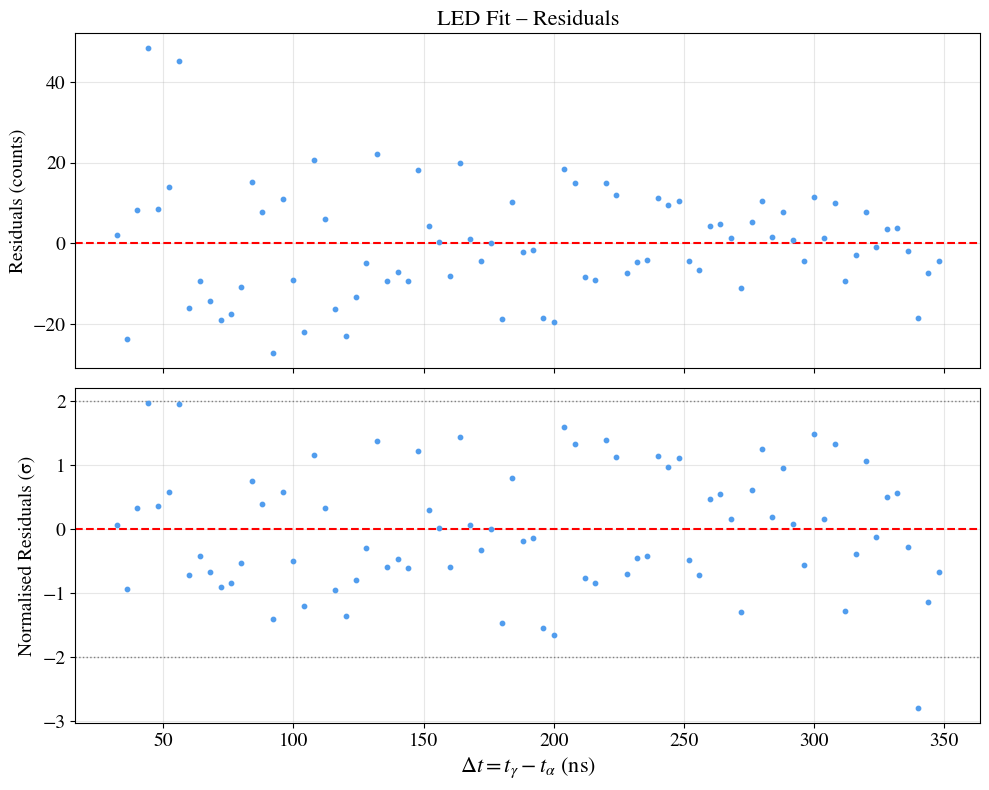

In [41]:
fit_mask_res = (bin_centres >= t_min_fit) & (bin_centres <= t_max_fit) & (counts > 0)
x_res = bin_centres[fit_mask_res]
y_res = counts[fit_mask_res].astype(float)
y_model_res = exp_free_bg_led(x_res, *popt)
sigma_res = np.sqrt(np.maximum(y_model_res, 1.0))
residuals = y_res - y_model_res
norm_residuals = residuals / sigma_res

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# raw resids
ax1.scatter(x_res, residuals, color="#519DEE", s=10, zorder=3)
ax1.axhline(0, color='red', lw=1.5, linestyle='--')
ax1.set_ylabel('Residuals (counts)', fontsize=14)
ax1.set_title('LED Fit – Residuals', fontsize=16)
ax1.tick_params(axis='both', labelsize=14)
ax1.grid(alpha=0.3)

# normalised resids
ax2.scatter(x_res, norm_residuals, color="#519DEE", s=10, zorder=3)
ax2.axhline(0,  color='red',  lw=1.5, linestyle='--')
ax2.axhline(2,  color='grey', lw=1,   linestyle=':')
ax2.axhline(-2, color='grey', lw=1,   linestyle=':')
ax2.set_xlabel(r'$\Delta t = t_\gamma - t_\alpha$ (ns)', fontsize=16)
ax2.set_ylabel('Normalised Residuals (σ)', fontsize=14)
ax2.tick_params(axis='both', labelsize=14)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('LED_residuals')
plt.show()

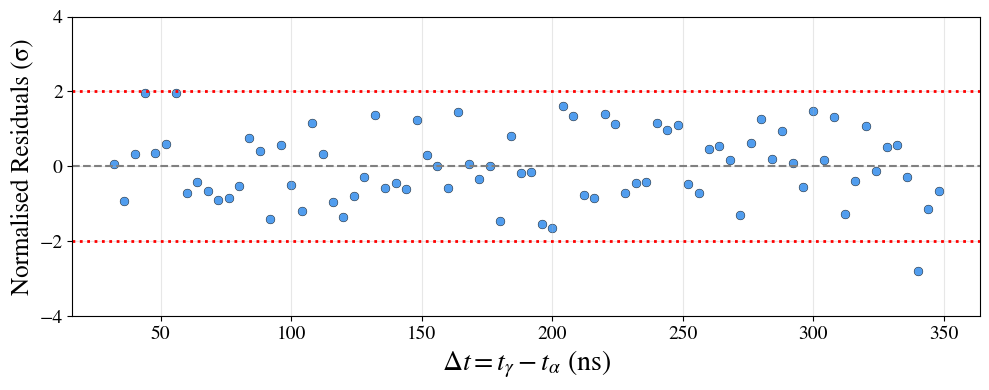

In [42]:
fit_mask_res = (bin_centres >= t_min_fit) & (bin_centres <= t_max_fit) & (counts > 0)
x_res = bin_centres[fit_mask_res]
y_res = counts[fit_mask_res].astype(float)
y_model_res = exp_free_bg_led(x_res, *popt)
sigma_res = np.sqrt(np.maximum(y_model_res, 1.0))
residuals = y_res - y_model_res
norm_residuals = residuals / sigma_res

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(x_res, norm_residuals, color="#519DEE", s=40, marker='o',
           edgecolors='black', linewidths=0.3)
ax.axhline(0,  color='grey', lw=1.5, linestyle='--')
ax.axhline(2,  color='red',  lw=2,   linestyle=':')
ax.axhline(-2, color='red',  lw=2,   linestyle=':')
ax.set_xlabel(r'$\Delta t = t_\gamma - t_\alpha$ (ns)', fontsize=20)
ax.set_ylabel('Normalised Residuals (σ)', fontsize=18)
#ax.set_title('LED Timing – Normalised Residuals', fontsize=20)
ax.set_ylim(-4, 4)
ax.tick_params(axis='both', labelsize=14)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('LED_residuals')
plt.show()

# CFD FINAL PLOTS

CFD coincidences: 29727
Initial background estimate B = 16.57 ± 0.48 counts/bin

CFD timing fit results
  Mean lifetime   = 98.60 ± 2.96 ns
  Halflife   = 68.34 ± 2.05 ns
  B     = 21.86 ± 4.03 counts/bin (fitted)
  chisquared          = 1.04


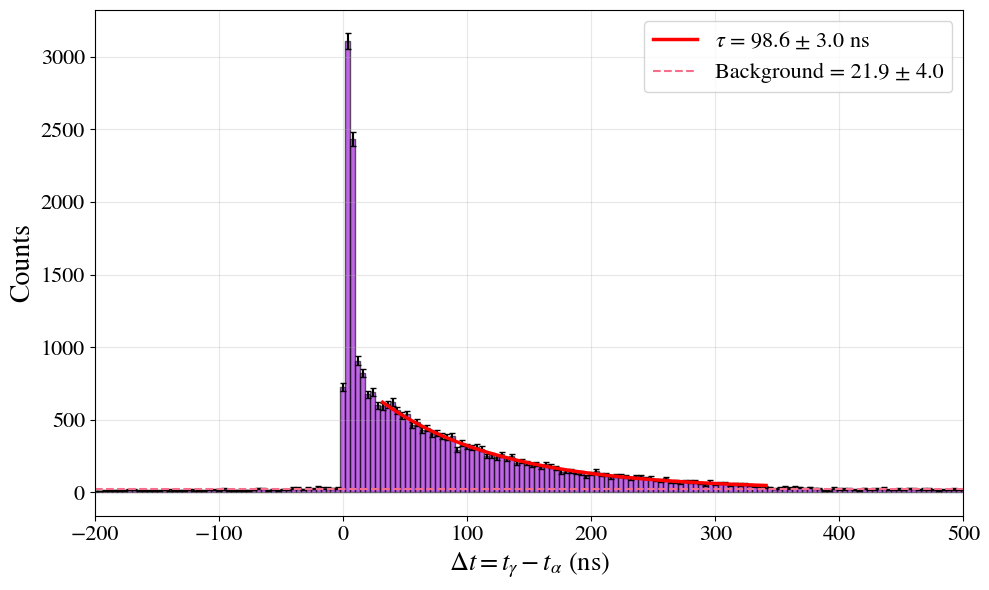

In [43]:

print(f"CFD coincidences: {len(dt_coinc_CFD)}")

window_ns = 850
bin_width = 4
dt_step_ns = bin_width

counts, bin_edges = np.histogram(
    dt_coinc_CFD,
    bins=np.arange(-450, 850 + bin_width, bin_width)
)
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

bg_mask = (bin_centres < -20) & (bin_centres > -400)
B_init = counts[bg_mask].mean()
B_fixed_err = counts[bg_mask].std() / np.sqrt(bg_mask.sum())
print(f"Initial background estimate B = {B_init:.2f} ± {B_fixed_err:.2f} counts/bin")

def exp_free_bg(t, A, tau, B):
    return A * np.exp(-t / tau) + B

t_min_fit = 32
t_max_fit = 341

fit_mask = (bin_centres >= t_min_fit) & (bin_centres <= t_max_fit) & (counts > 0)

x_fitcfd = bin_centres[fit_mask]
y_fitcfd = counts[fit_mask].astype(float)
sigma_fitcfd = np.sqrt(np.maximum(y_fitcfd, 1.0))

A0 = y_fitcfd.max()
tau0 = 100.0

popt, pcov = curve_fit(
    exp_free_bg,
    x_fitcfd, y_fitcfd,
    p0=[A0, tau0, B_init],
    sigma=sigma_fitcfd, 
    absolute_sigma=True,
    bounds=([0, 1e-6, 0], [np.inf, np.inf, np.inf]),
    maxfev=200000
)

sigma_fit2cfd = np.sqrt(np.maximum(exp_free_bg(x_fitcfd, *popt), 1.0))
popt, pcov = curve_fit(
    exp_free_bg,
    x_fitcfd, y_fitcfd,
    p0=popt,
    sigma=sigma_fit2cfd, absolute_sigma=True,
    bounds=([0, 1e-6, 0], [np.inf, np.inf, np.inf]),
    maxfev=200000
)

A_fit, tau_fit, B_fit = popt
A_err, tau_err, B_err = np.sqrt(np.diag(pcov))

y_modelcfd = exp_free_bg(x_fitcfd, *popt)
chi2 = np.sum(((y_fitcfd - y_modelcfd) / sigma_fit2cfd) ** 2)
dof = len(x_fitcfd) - 3  
chi2_dof = chi2 / dof if dof > 0 else np.nan

T12 = tau_fit * np.log(2)
T12_err = tau_err * np.log(2)

print("\nCFD timing fit results")
print(f"  Mean lifetime   = {tau_fit:.2f} ± {tau_err:.2f} ns")
print(f"  Halflife   = {T12:.2f} ± {T12_err:.2f} ns")
print(f"  B     = {B_fit:.2f} ± {B_err:.2f} counts/bin (fitted)")
print(f"  chisquared          = {chi2_dof:.2f}")


t_plot = np.linspace(t_min_fit, t_max_fit, 600)

fig, ax = plt.subplots(figsize=(10, 6))

plot_mask = bin_centres >= -450

ax.bar(
    bin_edges[:-1][plot_mask], counts[plot_mask],
    width=dt_step_ns, align='edge',
    alpha=0.6, edgecolor='black', color="#9400d3"
)
ax.errorbar(
    bin_centres[plot_mask], counts[plot_mask],
    yerr=np.sqrt(np.maximum(counts[plot_mask].astype(float), 1.0)),
    fmt='none', ecolor='black', capsize=2
)
ax.plot(
    t_plot, exp_free_bg(t_plot, *popt),
    'r', lw=2.5,
    label=rf"$\tau$ = {tau_fit:.1f} ± {tau_err:.1f} ns"
)
ax.axhline(B_fit, color="#f66e8b", linewidth=1.5, linestyle='--',
           label=f'Background = {B_fit:.1f} ± {B_err:.1f}')

ax.set_xlim(-200, 500)
ax.set_xlabel(r'$\Delta t = t_\gamma - t_\alpha$ (ns)', fontsize=19)
ax.set_ylabel('Counts', fontsize=20)
ax.tick_params(axis='both', labelsize=16)
#ax.set_title('CFD Timing – Lifetime Fit', fontsize=22)
ax.legend(fontsize=16)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('CFDReport')
plt.show()

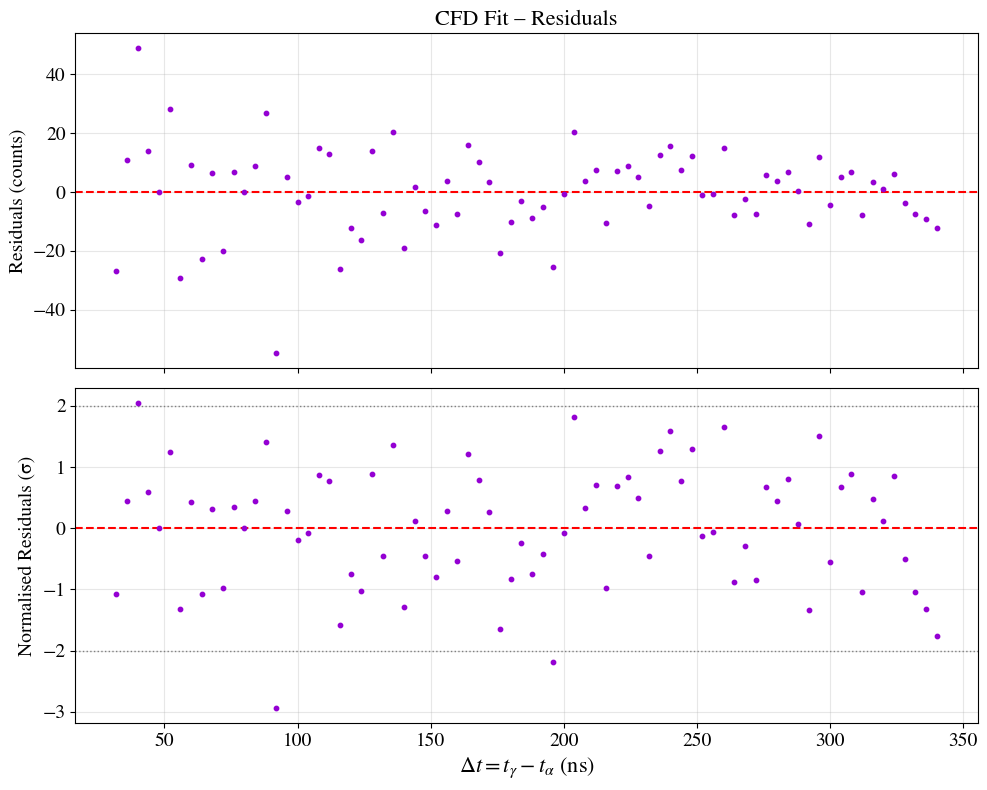

In [44]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

fit_mask = (bin_centres >= t_min_fit) & (bin_centres <= t_max_fit) & (counts > 0)
x_fit = bin_centres[fit_mask]
y_fit = counts[fit_mask].astype(float)

y_model_fit = exp_free_bg(x_fit, *popt)
sigma_fit2 = np.sqrt(np.maximum(y_model_fit, 1.0))
residualscfd = y_fit - y_model_fit
norm_residualscfd = residualscfd / sigma_fit2


ax1.scatter(x_fit, residualscfd, color="#9400d3", s=10, zorder=3)
ax1.axhline(0, color='red', lw=1.5, linestyle='--')
ax1.set_ylabel('Residuals (counts)', fontsize=14)
ax1.set_title('CFD Fit – Residuals', fontsize=16)
ax1.tick_params(axis='both', labelsize=14)
ax1.grid(alpha=0.3)


ax2.scatter(x_fit, norm_residualscfd, color="#9400d3", s=10, zorder=3)
ax2.axhline(0,  color='red',  lw=1.5, linestyle='--')
ax2.axhline(2,  color='grey', lw=1,   linestyle=':')
ax2.axhline(-2, color='grey', lw=1,   linestyle=':')
ax2.set_xlabel(r'$\Delta t = t_\gamma - t_\alpha$ (ns)', fontsize=16)
ax2.set_ylabel('Normalised Residuals (σ)', fontsize=14)
ax2.tick_params(axis='both', labelsize=14)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('CFD_residuals')
plt.show()

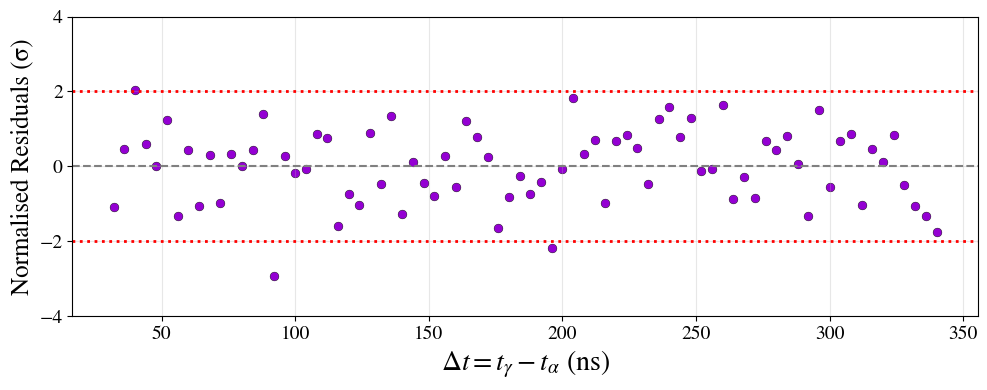

In [45]:
fit_mask = (bin_centres >= t_min_fit) & (bin_centres <= t_max_fit) & (counts > 0)
x_fitcfd = bin_centres[fit_mask]
y_fitcfd = counts[fit_mask].astype(float)

y_model_fit = exp_free_bg(x_fitcfd, *popt)
sigma_fit2cfd = np.sqrt(np.maximum(y_model_fit, 1.0))
residualscfd = y_fitcfd - y_model_fit
norm_residualscfd = residualscfd / sigma_fit2cfd 

fig, ax = plt.subplots(figsize=(10, 4))

ax.scatter(x_fitcfd, norm_residualscfd, color="#9400d3", s=40, marker='o',
           edgecolors='black', linewidths=0.3)
ax.axhline(0,  color='grey', lw=1.5, linestyle='--')
ax.axhline(2,  color='red',  lw=2,   linestyle=':')
ax.axhline(-2, color='red',  lw=2,   linestyle=':')
ax.set_xlabel(r'$\Delta t = t_\gamma - t_\alpha$ (ns)', fontsize=20)
ax.set_ylabel('Normalised Residuals (σ)', fontsize=18)
#ax.set_title('CFD Timing – Normalised Residuals', fontsize=20)
ax.set_ylim(-4, 4)
ax.tick_params(axis='both', labelsize=14)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('CFD_residuals')
plt.show()

# FWHM

Common events: 32176
  0/32176 waveforms processed...
  0/32176 waveforms processed...
  0/32176 waveforms processed...
  0/32176 waveforms processed...
  0/32176 waveforms processed...
  0/32176 waveforms processed...


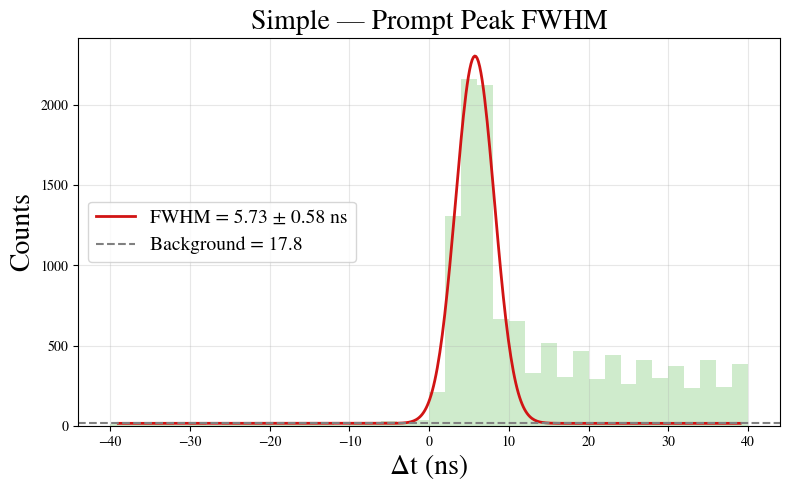

Simple: FWHM = 5.73 ± 0.58 ns, μ = 5.7 ± 0.24 ns


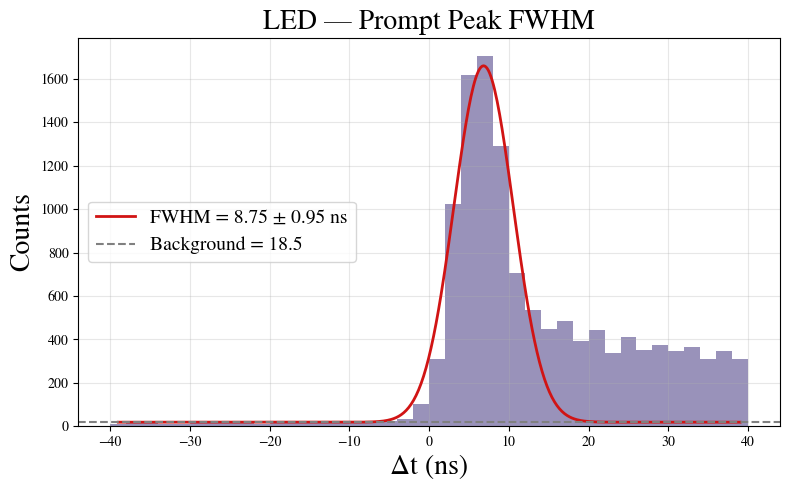

LED: FWHM = 8.75 ± 0.95 ns, μ = 6.8 ± 0.38 ns


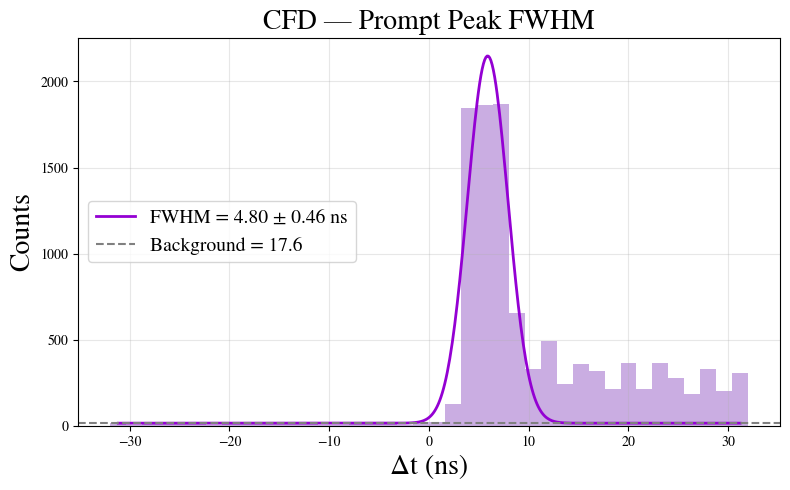

CFD: FWHM = 4.80 ± 0.46 ns, μ = 5.9 ± 0.19 ns

FWHM Summary:
  Simple : 5.73 ± 0.58 ns
  LED    : 8.75 ± 0.95 ns
  CFD    : 4.80 ± 0.46 ns


In [46]:
def gaussian(t, A, mu, sig, B):
    return A * np.exp(-0.5 * ((t - mu) / sig)**2) + B

def prompt_fwhm(dt, label, half_window=20, bar_color='steelblue', line_color='red'):
    fig, ax = plt.subplots(figsize=(8, 5))

    mask = (dt > -half_window*4) & (dt < half_window*4)
    counts_g, edges_g = np.histogram(dt[mask], bins=40)
    centres_g = (edges_g[:-1] + edges_g[1:]) / 2
    bin_w_g = edges_g[1] - edges_g[0]

    B_init = counts_g[centres_g < -5].mean()
    mu_guess = centres_g[np.argmax(counts_g)]

    try:
        popt_g, pcov_g = curve_fit(
            gaussian, centres_g, counts_g,
            p0=[counts_g.max(), mu_guess, 3, B_init],
            bounds=([0, -50, 0.1, 0], [np.inf, 50, 100, B_init * 1.2]),
            maxfev=10000
        )
        A_g, mu_g, sig_g, B_g = popt_g
        perr_g = np.sqrt(np.diag(pcov_g))

        fwhm = 2.355 * abs(sig_g)
        fwhm_err = 2.355 * perr_g[2]

        t_fine = np.linspace(centres_g.min(), centres_g.max(), 500)
        ax.bar(centres_g, counts_g, width=bin_w_g, color=bar_color, alpha=0.5)
        ax.plot(t_fine, gaussian(t_fine, *popt_g), color=line_color, linewidth=2,
                label=f'FWHM = {fwhm:.2f} ± {fwhm_err:.2f} ns')
        ax.axhline(B_g, color='grey', lw=1.5, linestyle='--',
                   label=f'Background = {B_g:.1f}')
        ax.set_xlabel('Δt (ns)', fontsize=20)
        ax.set_ylabel('Counts', fontsize=20)
        ax.set_title(f'{label} — Prompt Peak FWHM', fontsize=20)
        ax.legend(fontsize=14, loc='center left', frameon=True)
        for spine in ax.spines.values():
            spine.set_visible(True)
        plt.tight_layout()
        plt.grid(alpha=0.3)
        plt.show()

        print(f"{label}: FWHM = {fwhm:.2f} ± {fwhm_err:.2f} ns, μ = {mu_g:.1f} ± {perr_g[1]:.2f} ns")
        return fwhm, fwhm_err, popt_g

    except Exception as e:
        print(f"{label}: fit failed — {e}")
        return np.nan, np.nan, None


#since im making comparsion plots i need to have a common event range for fair comparison ( having same threshold for all three timing emthods)

alpha_trig = Pulses_corrected_alpha.min(axis=1) < -100
gamma_trig = Pulses_corrected.min(axis=1) < -100
both = alpha_trig & gamma_trig
print("Common events:", both.sum())


alpha_t_simple = simple_min_timing_linear(Pulses_corrected_alpha[both], amp_threshold=-100)
gamma_t_simple = simple_min_timing_linear(Pulses_corrected[both],       amp_threshold=-100)
dt_simple_same = (gamma_t_simple - alpha_t_simple) * 4
dt_simple_same = dt_simple_same[np.isfinite(dt_simple_same)]

alpha_t_led = leading_edge_timing_linear(Pulses_corrected_alpha[both], threshold=-100)
gamma_t_led = leading_edge_timing_linear(Pulses_corrected[both],       threshold=-100)
dt_led_same = (gamma_t_led - alpha_t_led) * 4
dt_led_same = dt_led_same[np.isfinite(dt_led_same)]

alpha_t_cfd = cfd_timing(Pulses_corrected_alpha[both], fraction=0.2, delay_samples=3, amp_threshold=-100)
gamma_t_cfd = cfd_timing(Pulses_corrected[both],       fraction=0.2, delay_samples=3, amp_threshold=-100)
dt_cfd_same = (gamma_t_cfd - alpha_t_cfd) * 4
dt_cfd_same = dt_cfd_same[np.isfinite(dt_cfd_same)]


fwhm_simple, err_simple, popt_simple = prompt_fwhm(dt_simple_same, "Simple", half_window=10,
                                                                   bar_color="#a1d99b", line_color="#d11414")
fwhm_led,    err_led,    popt_led    = prompt_fwhm(dt_led_same,    "LED",    half_window=10,
                                                                   bar_color="#352677", line_color="#d11414")
fwhm_cfd,    err_cfd,    popt_cfd    = prompt_fwhm(dt_cfd_same,    "CFD",    half_window=8,
                                                                   bar_color="#975dc7", line_color="#9400d3")

print(f"\nFWHM Summary:")
print(f"  Simple : {fwhm_simple:.2f} ± {err_simple:.2f} ns")
print(f"  LED    : {fwhm_led:.2f} ± {err_led:.2f} ns")
print(f"  CFD    : {fwhm_cfd:.2f} ± {err_cfd:.2f} ns")

Simple: FWHM = 5.73 ± 0.58 ns, μ = 5.7 ± 0.24 ns
LED: FWHM = 8.75 ± 0.95 ns, μ = 6.8 ± 0.38 ns
CFD: FWHM = 4.13 ± 0.38 ns, μ = 5.9 ± 0.15 ns


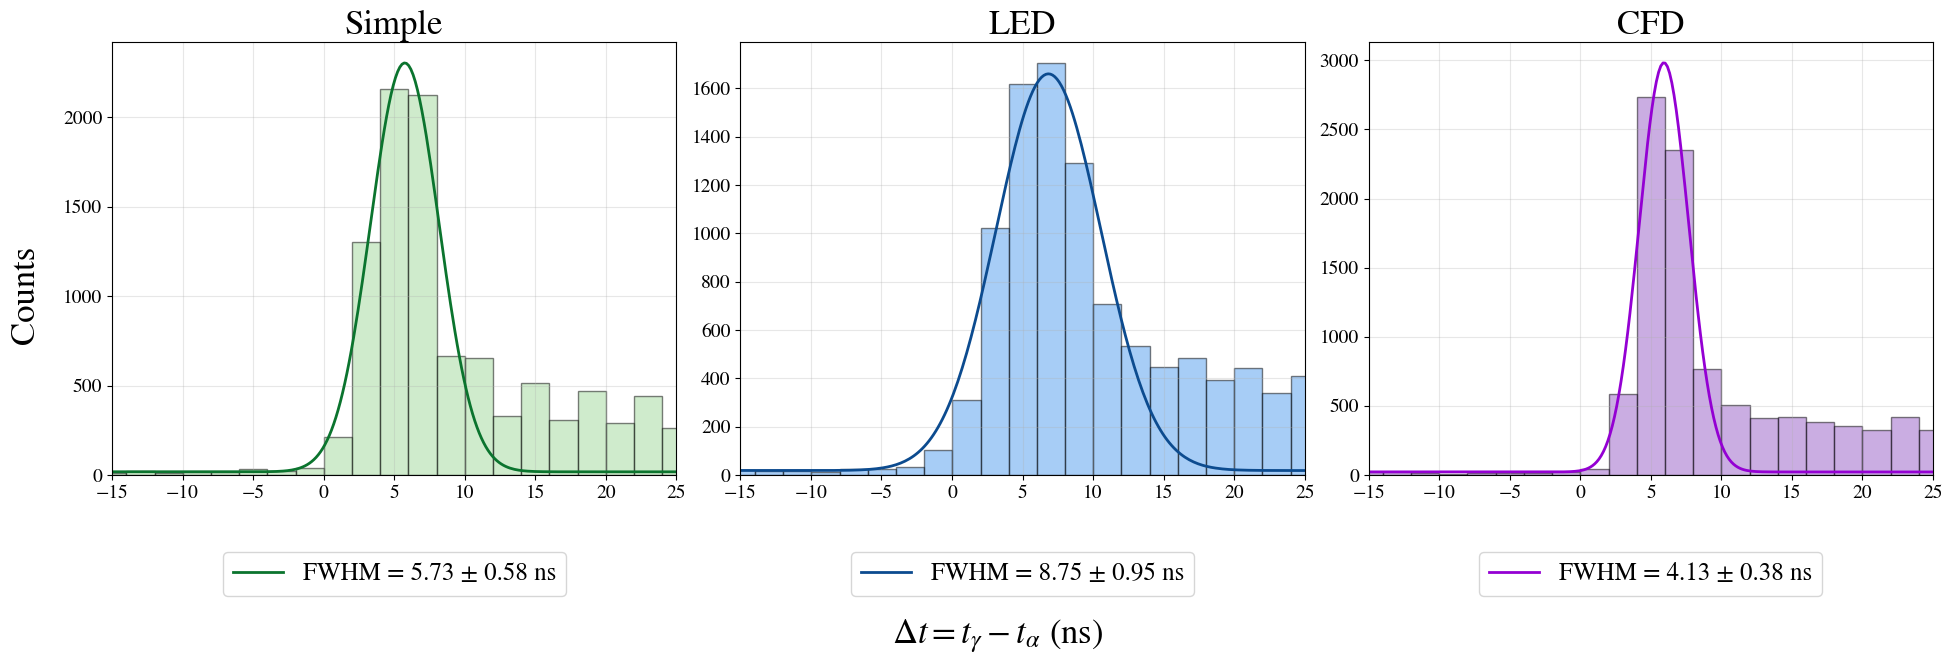


FWHM Summary:
  Simple : 5.73 ± 0.58 ns
  LED    : 8.75 ± 0.95 ns
  CFD    : 4.13 ± 0.38 ns


In [49]:
def prompt_fwhm(dt, label, ax, half_window=20, bar_color='steelblue', line_color='red'):
    mask = (dt > -half_window*4) & (dt < half_window*4)
    counts_g, edges_g = np.histogram(dt[mask], bins=40)
    centres_g = (edges_g[:-1] + edges_g[1:]) / 2
    bin_w_g = edges_g[1] - edges_g[0]

    B_init = counts_g[centres_g < -5].mean()
    mu_guess = centres_g[np.argmax(counts_g)]

    try:
        popt_g, pcov_g = curve_fit(
            gaussian, centres_g, counts_g,
            p0=[counts_g.max(), mu_guess, 3, B_init],
            bounds=([0, -50, 0.1, 0], [np.inf, 50, 100, B_init * 1.2]),
            maxfev=10000
        )
        A_g, mu_g, sig_g, B_g = popt_g
        perr_g = np.sqrt(np.diag(pcov_g))

        fwhm = 2.355 * abs(sig_g)
        fwhm_err = 2.355 * perr_g[2]

        t_fine = np.linspace(centres_g.min(), centres_g.max(), 500)
        ax.bar(centres_g, counts_g, width=bin_w_g, color=bar_color, alpha=0.5, edgecolor='black')
        ax.plot(t_fine, gaussian(t_fine, *popt_g), color=line_color, linewidth=2,
                label=f'FWHM = {fwhm:.2f} ± {fwhm_err:.2f} ns')
        
        
        ax.set_title(f'{label}', fontsize=25)
        ax.legend(fontsize=18, frameon=True, loc='upper center', 
          bbox_to_anchor=(0.5, -0.15), ncol=1)
        ax.tick_params(axis='both', labelsize=14)
        ax.grid(alpha=0.3)
        ax.set_xlim(-15, 25)

        print(f"{label}: FWHM = {fwhm:.2f} ± {fwhm_err:.2f} ns, μ = {mu_g:.1f} ± {perr_g[1]:.2f} ns")
        return fwhm, fwhm_err, popt_g

    except Exception as e:
        print(f"{label}: fit failed — {e}")
        return np.nan, np.nan, None



fig, axes = plt.subplots(1, 3, figsize=(19, 6))

fwhm_simple, err_simple, popt_simple = prompt_fwhm(
    dt_simple_same, "Simple", axes[0], half_window=10,
    bar_color='#a1d99b', line_color="#0b742e")

fwhm_led, err_led, popt_led = prompt_fwhm(
    dt_led_same, "LED", axes[1], half_window=10,
    bar_color="#519DEE", line_color="#0C4B8F")

fwhm_cfd, err_cfd, popt_cfd = prompt_fwhm(
    dt_cfd_same, "CFD", axes[2], half_window=10,
    bar_color="#975dc7", line_color="#9400d3")



plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
fig.supxlabel(r'$\Delta t = t_\gamma - t_\alpha$ (ns)', fontsize=25, y=-0.1)
fig.supylabel('Counts', fontsize=25, x=-0.02)
plt.savefig('FWHM_sidebyside')
plt.show()

print(f"\nFWHM Summary:")
print(f"  Simple : {fwhm_simple:.2f} ± {err_simple:.2f} ns")
print(f"  LED    : {fwhm_led:.2f} ± {err_led:.2f} ns")
print(f"  CFD    : {fwhm_cfd:.2f} ± {err_cfd:.2f} ns")

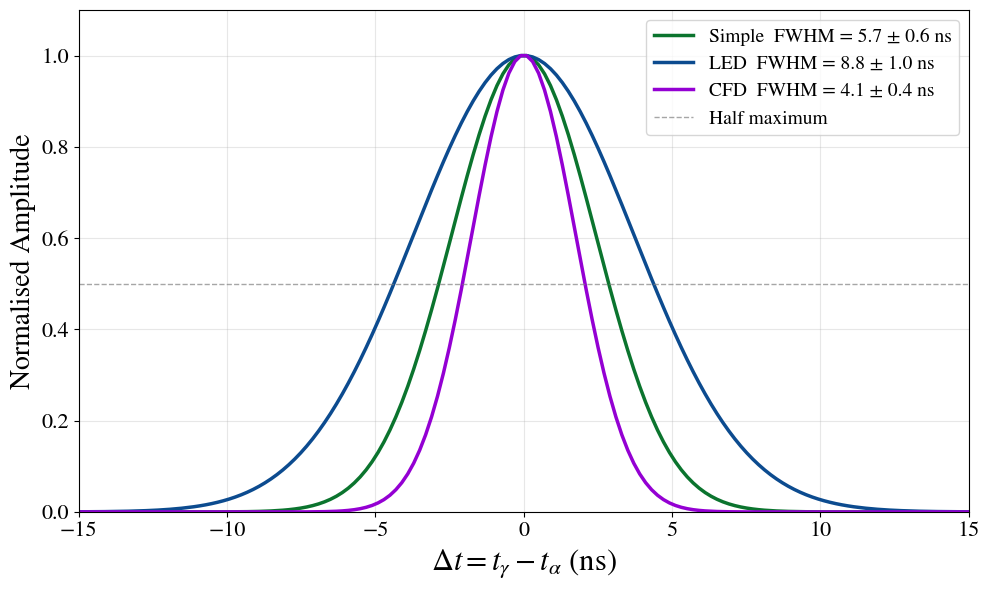

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))

datasets = [
    (dt_simple_same, 'Simple', "#0b742e", popt_simple, err_simple),
    (dt_led_same,    'LED',    "#0C4B8F", popt_led,    err_led),
    (dt_cfd_same,    'CFD',    "#9400d3", popt_cfd,    err_cfd),
]

for dt, label, color, popt, fwhm_err in datasets:
    A_fit, mu_fit, sigma_fit, B_fit = popt
    fwhm = 2.355 * abs(sigma_fit)

    x_plot = np.linspace(-50, 50, 500)
    y_plot = gaussian(x_plot + mu_fit, *popt) - B_fit
    y_plot_norm = y_plot / y_plot.max()

    ax.plot(x_plot, y_plot_norm, color=color, lw=2.5,
            label=f'{label}  FWHM = {fwhm:.1f} ± {fwhm_err:.1f} ns')

ax.axhline(0.5, color='grey', linestyle='--', lw=1, alpha=0.7, label='Half maximum')
ax.set_xlabel(r'$\Delta t = t_\gamma - t_\alpha$ (ns)', fontsize=22)
ax.set_ylabel('Normalised Amplitude', fontsize=20)
#ax.set_title('FWHM Comparison', fontsize=22)
ax.set_xlim(-15, 15)
ax.set_ylim(0, 1.1)
ax.tick_params(axis='both', labelsize=16)
ax.legend(fontsize=14)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('FWHM_overlay_normalised')
plt.show()

# time walk graph

  0/32176 waveforms processed...
  0/32176 waveforms processed...
  0/32176 waveforms processed...
  0/32176 waveforms processed...
  0/32176 waveforms processed...
  0/32176 waveforms processed...


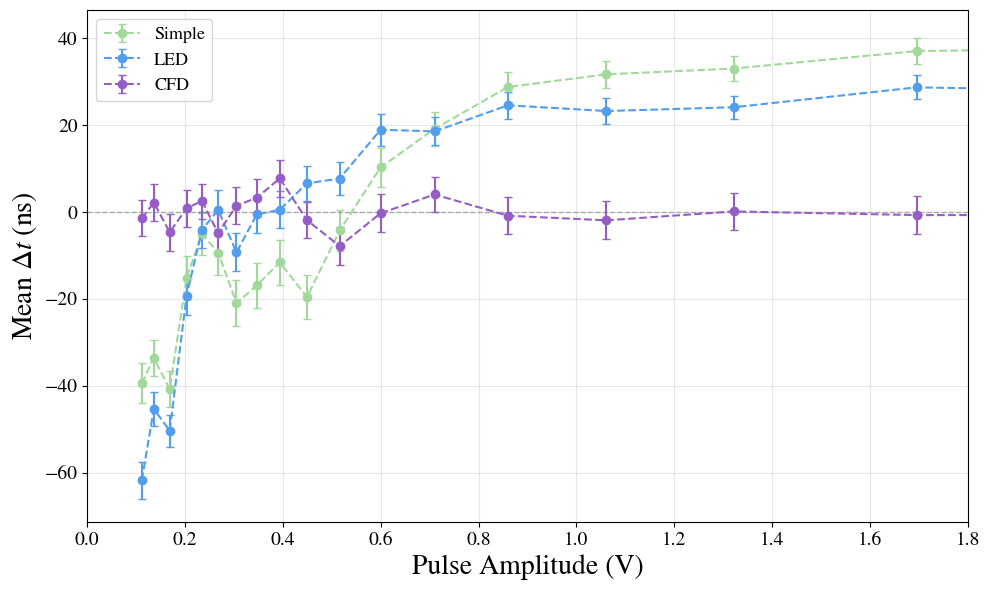

In [51]:
fig, ax = plt.subplots(figsize=(10, 6))

both_walk = (Pulses_corrected_alpha.min(axis=1) < -100) & \
            (Pulses_corrected.min(axis=1) < -100)


alpha_t_simple_walk = simple_min_timing_linear(Pulses_corrected_alpha[both_walk], amp_threshold=-100)
gamma_t_simple_walk = simple_min_timing_linear(Pulses_corrected[both_walk], amp_threshold=-100)
dt_simple_walk = (gamma_t_simple_walk - alpha_t_simple_walk) * 4
dt_simple_walk = dt_simple_walk[np.isfinite(dt_simple_walk)]

alpha_t_led_walk = leading_edge_timing_linear(Pulses_corrected_alpha[both_walk], threshold=-100)
gamma_t_led_walk = leading_edge_timing_linear(Pulses_corrected[both_walk], threshold=-100)
dt_led_walk = (gamma_t_led_walk - alpha_t_led_walk) * 4
dt_led_walk = dt_led_walk[np.isfinite(dt_led_walk)]

alpha_t_cfd_walk = cfd_timing(Pulses_corrected_alpha[both_walk], fraction=0.3, delay_samples=5, amp_threshold=-100)
gamma_t_cfd_walk = cfd_timing(Pulses_corrected[both_walk], fraction=0.3, delay_samples=5, amp_threshold=-100)
dt_cfd_walk = (gamma_t_cfd_walk - alpha_t_cfd_walk) * 4
dt_cfd_walk = dt_cfd_walk[np.isfinite(dt_cfd_walk)]

amps = -Pulses_corrected_alpha[both_walk].min(axis=1) / 1000

datasets = [
    (dt_simple_walk, 'Simple', '#a1d99b'),
    (dt_led_walk,    'LED',    "#519DEE"),
    (dt_cfd_walk,    'CFD',    "#975dc7"),
]

for dt, label, color in datasets:
    n = min(len(dt), len(amps))
    a = amps[:n]
    t = dt[:n]

    amp_bins = np.percentile(a, np.linspace(0, 100, 20))
    amp_centres = 0.5 * (amp_bins[:-1] + amp_bins[1:])
    mean_dt = []
    err_dt = []

    for i in range(len(amp_bins) - 1):
        mask = (a >= amp_bins[i]) & (a < amp_bins[i+1])
        vals = t[mask]
        if len(vals) > 5:
            mean_dt.append(np.mean(vals))
            err_dt.append(np.std(vals) / np.sqrt(len(vals)))
        else:
            mean_dt.append(np.nan)
            err_dt.append(np.nan)

    mean_dt = np.array(mean_dt)
    err_dt = np.array(err_dt)
    mean_dt -= np.nanmean(mean_dt)

    ax.errorbar(amp_centres, mean_dt, yerr=err_dt,
            fmt='o--', color=color, label=label, capsize=3, lw=1.5)

ax.axhline(0, color='grey', linestyle='--', lw=1, alpha=0.6)
ax.set_xlabel('Pulse Amplitude (V)', fontsize=20)
ax.set_ylabel(r'Mean $\Delta t$ (ns)', fontsize=20)
ax.set_xlim(0, 1.8)
#ax.set_title('Time Walk Comparison', fontsize=22)
ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=13)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('timewalk_comparison')
plt.show()

  0/30554 waveforms processed...
  0/30554 waveforms processed...
fraction=10% → FWHM=5.13±0.56 ns, τ=97.47±2.86 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
fraction=15% → FWHM=4.99±0.52 ns, τ=97.57±2.86 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
fraction=20% → FWHM=4.89±0.48 ns, τ=97.77±2.87 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
fraction=25% → FWHM=4.84±0.45 ns, τ=97.42±2.85 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
fraction=30% → FWHM=4.77±0.43 ns, τ=97.29±2.85 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
fraction=35% → FWHM=4.68±0.41 ns, τ=97.23±2.85 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
fraction=40% → FWHM=4.64±0.41 ns, τ=97.62±2.87 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
fraction=45% → FWHM=4.62±0.40 ns, τ=97.68±2.87 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
fracti

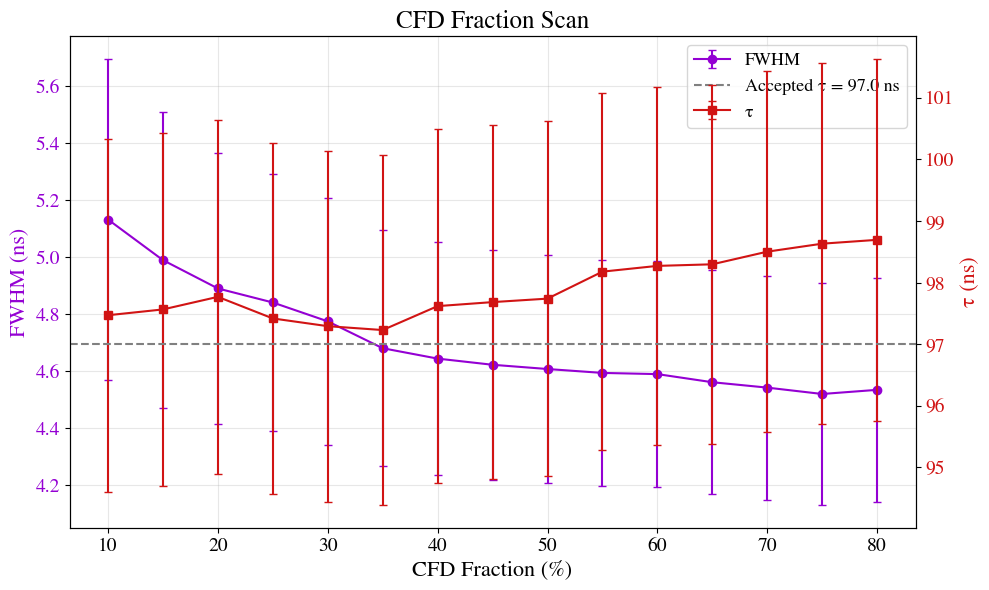

In [63]:
alpha_amps_v = Pulses_corrected_alpha.min(axis=1) * volts_per_count
gamma_amps_v = Pulses_corrected.min(axis=1) * volts_per_count

alpha_trig = (Pulses_corrected_alpha.min(axis=1) < -100) & (alpha_amps_v > -1.74)
gamma_trig = (Pulses_corrected.min(axis=1) < -100) & (gamma_amps_v > -1.54)
both = alpha_trig & gamma_trig

def exp_cfd(t, A, tau, B):
    return A * np.exp(-t / tau) + B

fractions = np.arange(0.10, 0.85, 0.05)
delay = 3

results_frac = []

for frac in fractions:
    a_times = cfd_timing(Pulses_corrected_alpha[both], fraction=frac,
                         delay_samples=delay, amp_threshold=-100)
    g_times = cfd_timing(Pulses_corrected[both], fraction=frac,
                         delay_samples=delay, amp_threshold=-100)

    dt = (g_times - a_times) * 4
    dt_clean = dt[np.isfinite(dt)]
    dt_coinc = dt_clean[(dt_clean > -450) & (dt_clean < 850)]

    if len(dt_coinc) < 100:
        continue

   
    mask = (dt_coinc > -32) & (dt_coinc < 32)  
    counts_g, edges_g = np.histogram(dt_coinc[mask], bins=40)
    centres_g = (edges_g[:-1] + edges_g[1:]) / 2
    B_init_g = counts_g[centres_g < -5].mean()

    try:
        popt_g, pcov_g = curve_fit(
            gaussian, centres_g, counts_g,
            p0=[counts_g.max(), 0.0, 5.0, B_init_g],
            bounds=([0, -50, 0.1, 0], [np.inf, 50, 100, B_init_g * 1.2]),
            maxfev=10000
        )
        fwhm = 2.355 * abs(popt_g[2])
        fwhm_err = 2.355 * np.sqrt(pcov_g[2, 2])
    except:
        fwhm, fwhm_err = np.nan, np.nan

    
    counts_h, bin_edges_h = np.histogram(dt_coinc, bins=np.arange(-450, 854, 4))
    bin_centres_h = 0.5 * (bin_edges_h[:-1] + bin_edges_h[1:])

    B_init = counts_h[(bin_centres_h < -20) & (bin_centres_h > -400)].mean()

   

    fit_mask = (bin_centres_h >= 32) & (bin_centres_h <= 342) & (counts_h > 0)
    x_fit = bin_centres_h[fit_mask]
    y_fit = counts_h[fit_mask].astype(float)
    sigma = np.sqrt(np.maximum(y_fit, 1.0))

    try:
        popt, pcov = curve_fit(
            exp_cfd, x_fit, y_fit,
            p0=[y_fit.max(), 100.0, B_init],
            sigma=sigma, absolute_sigma=True,
            bounds=([0, 1e-6, 0], [np.inf, np.inf, np.inf]),
            maxfev=200000
        )
        sigma2 = np.sqrt(np.maximum(exp_cfd(x_fit, *popt), 1.0))
        popt, pcov = curve_fit(
            exp_cfd, x_fit, y_fit,
            p0=popt,
            sigma=sigma2, absolute_sigma=True,
            bounds=([0, 1e-6, 0], [np.inf, np.inf, np.inf]),
            maxfev=200000
        )
        tau = popt[1]
        tau_err = np.sqrt(pcov[1, 1])
    except:
        tau, tau_err = np.nan, np.nan

    results_frac.append({
        'fraction': frac * 100,  
        'fwhm': fwhm, 'fwhm_err': fwhm_err,
        'tau': tau, 'tau_err': tau_err
    })
    print(f"fraction={frac*100:.0f}% → FWHM={fwhm:.2f}±{fwhm_err:.2f} ns, τ={tau:.2f}±{tau_err:.2f} ns")

df_frac = pd.DataFrame(results_frac)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.errorbar(df_frac['fraction'], df_frac['fwhm'], yerr=df_frac['fwhm_err'],
             fmt='o-', color='#9400d3', capsize=3, lw=1.5, label='FWHM')
ax2.errorbar(df_frac['fraction'], df_frac['tau'], yerr=df_frac['tau_err'],
             fmt='s-', color='#d11414', capsize=3, lw=1.5, label='τ')
ax2.axhline(97.0, color='grey', linestyle='--', lw=1.5, label='Accepted τ = 97.0 ns')

ax1.set_xlabel('CFD Fraction (%)', fontsize=16)
ax1.set_ylabel('FWHM (ns)', fontsize=16, color='#9400d3')
ax2.set_ylabel('τ (ns)', fontsize=16, color='#d11414')
ax1.tick_params(axis='y', labelcolor='#9400d3', labelsize=14)
ax2.tick_params(axis='y', labelcolor='#d11414', labelsize=14)
ax1.tick_params(axis='x', labelsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=13)

ax1.set_title('CFD Fraction Scan', fontsize=18)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('CFD_fraction_scan')
plt.show()

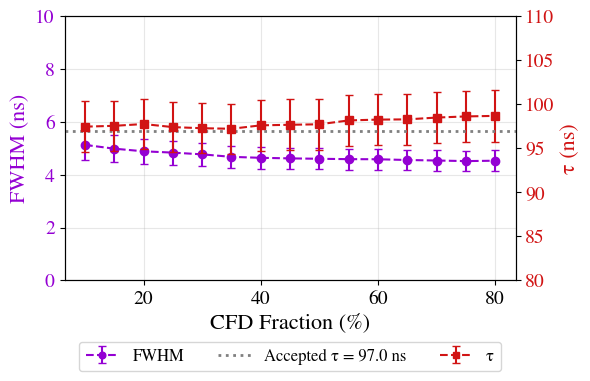

In [53]:
fig, ax1 = plt.subplots(figsize=(6,4))
ax2 = ax1.twinx()

ax1.errorbar(df_frac['fraction'], df_frac['fwhm'], yerr=df_frac['fwhm_err'],
             fmt='o--', color='#9400d3', capsize=3, lw=1.5, label='FWHM')
ax2.errorbar(df_frac['fraction'], df_frac['tau'], yerr=df_frac['tau_err'],
             fmt='s--', color='#d11414', capsize=3, lw=1.5, label='τ')
ax2.axhline(97.0, color='grey', linestyle=':', lw=2, label='Accepted τ = 97.0 ns')

ax1.set_xlabel('CFD Fraction (%)', fontsize=16)
               
ax1.set_ylabel('FWHM (ns)', fontsize=16, color='#9400d3')
ax2.set_ylabel('τ (ns)', fontsize=16, color='#d11414')
ax1.tick_params(axis='y', labelcolor='#9400d3', labelsize=14)
ax2.tick_params(axis='y', labelcolor='#d11414', labelsize=14)
ax1.tick_params(axis='x', labelsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=12, markerscale=0.8,
           loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)

#ax1.set_title('CFD Fraction Scan', fontsize=20)
ax1.set_ylim(0,10)
ax2.set_ylim(80,110)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('CFD_fraction_scan')
plt.show()

  0/30554 waveforms processed...
  0/30554 waveforms processed...
delay=4 ns → FWHM=6.05±1.48 ns, τ=76.84±1.88 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
delay=8 ns → FWHM=5.00±0.45 ns, τ=92.91±2.58 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
delay=12 ns → FWHM=4.91±0.44 ns, τ=97.77±2.87 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
delay=16 ns → FWHM=5.60±0.45 ns, τ=97.83±2.89 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
delay=20 ns → FWHM=6.59±0.63 ns, τ=98.54±2.95 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
delay=24 ns → FWHM=8.93±1.05 ns, τ=99.82±3.07 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
delay=28 ns → FWHM=10.34±1.32 ns, τ=100.29±3.13 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
delay=32 ns → FWHM=10.16±1.40 ns, τ=103.32±3.35 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
delay=36 ns 

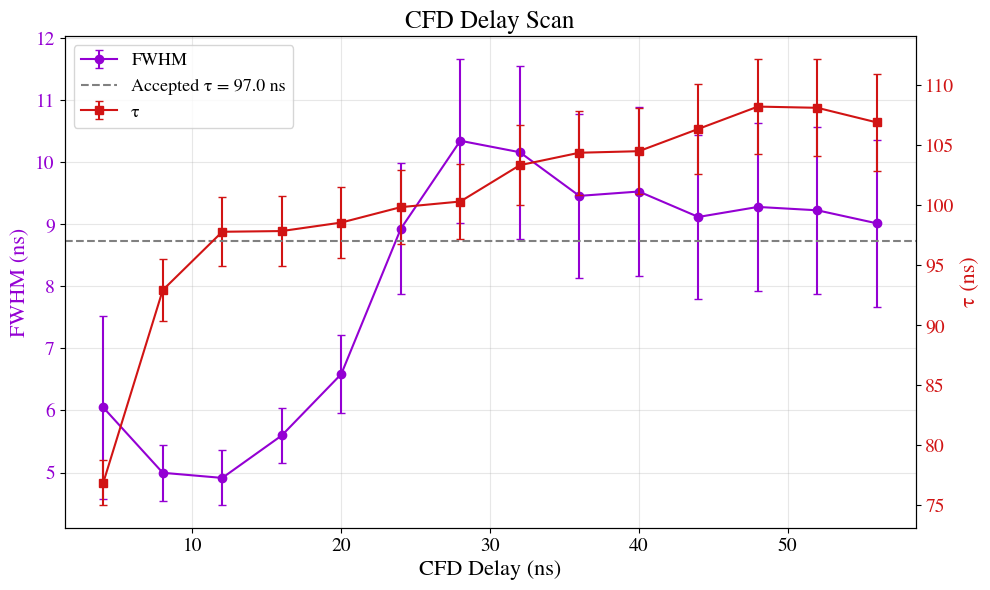

In [64]:
delays = np.arange(1, 15, 1)
frac_fixed = 0.20



results_delay = []

for delay in delays:
    a_times = cfd_timing(Pulses_corrected_alpha[both], fraction=frac_fixed,
                         delay_samples=delay, amp_threshold=-100)
    g_times = cfd_timing(Pulses_corrected[both], fraction=frac_fixed,
                         delay_samples=delay, amp_threshold=-100)

    dt = (g_times - a_times) * 4
    dt_clean = dt[np.isfinite(dt)]
    dt_coinc = dt_clean[(dt_clean > -450) & (dt_clean < 850)]

    if len(dt_coinc) < 100:
        continue

   
    mask = (dt_coinc > -80) & (dt_coinc < 80)
    counts_g, edges_g = np.histogram(dt_coinc[mask], bins=40)
    centres_g = (edges_g[:-1] + edges_g[1:]) / 2
    B_init_g = counts_g[centres_g < -5].mean()

    try:
        popt_g, pcov_g = curve_fit(
            gaussian, centres_g, counts_g,
            p0=[counts_g.max(), 0.0, 5.0, B_init_g],
            bounds=([0, -50, 0.1, 0], [np.inf, 50, 200, np.inf]),
            maxfev=50000
        )
        fwhm = 2.355 * abs(popt_g[2])
        fwhm_err = 2.355 * np.sqrt(pcov_g[2, 2])
    except Exception as e:
        fwhm, fwhm_err = np.nan, np.nan

    counts_h, bin_edges_h = np.histogram(dt_coinc, bins=np.arange(-450, 854, 4))
    bin_centres_h = 0.5 * (bin_edges_h[:-1] + bin_edges_h[1:])

    B_init = counts_h[(bin_centres_h < -20) & (bin_centres_h > -400)].mean()

    fit_mask = (bin_centres_h >= 32) & (bin_centres_h <= 342) & (counts_h > 0)
    x_fit = bin_centres_h[fit_mask]
    y_fit = counts_h[fit_mask].astype(float)
    sigma = np.sqrt(np.maximum(y_fit, 1.0))

    try:
        popt, pcov = curve_fit(
            exp_cfd, x_fit, y_fit,
            p0=[y_fit.max(), 100.0, B_init],
            sigma=sigma, absolute_sigma=True,
            bounds=([0, 1e-6, 0], [np.inf, np.inf, np.inf]),
            maxfev=200000
        )
        sigma2 = np.sqrt(np.maximum(exp_cfd(x_fit, *popt), 1.0))
        popt, pcov = curve_fit(
            exp_cfd, x_fit, y_fit,
            p0=popt,
            sigma=sigma2, absolute_sigma=True,
            bounds=([0, 1e-6, 0], [np.inf, np.inf, np.inf]),
            maxfev=200000
        )
        tau = popt[1]
        tau_err = np.sqrt(pcov[1, 1])
    except Exception as e:
        tau, tau_err = np.nan, np.nan

    results_delay.append({
        'delay': delay * 4,
        'fwhm': fwhm, 'fwhm_err': fwhm_err,
        'tau': tau, 'tau_err': tau_err
    })
    print(f"delay={delay*4:.0f} ns → FWHM={fwhm:.2f}±{fwhm_err:.2f} ns, τ={tau:.2f}±{tau_err:.2f} ns")

df_delay = pd.DataFrame(results_delay)


fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.errorbar(df_delay['delay'], df_delay['fwhm'], yerr=df_delay['fwhm_err'],
             fmt='o-', color='#9400d3', capsize=3, lw=1.5, label='FWHM')
ax2.errorbar(df_delay['delay'], df_delay['tau'], yerr=df_delay['tau_err'],
             fmt='s-', color='#d11414', capsize=3, lw=1.5, label='τ')
ax2.axhline(97.0, color='grey', linestyle='--', lw=1.5, label='Accepted τ = 97.0 ns')

ax1.set_xlabel('CFD Delay (ns)', fontsize=16)
ax1.set_ylabel('FWHM (ns)', fontsize=16, color='#9400d3')
ax2.set_ylabel('τ (ns)', fontsize=16, color='#d11414')
ax1.tick_params(axis='y', labelcolor='#9400d3', labelsize=14)
ax2.tick_params(axis='y', labelcolor='#d11414', labelsize=14)
ax1.tick_params(axis='x', labelsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=13)

ax1.set_title('CFD Delay Scan', fontsize=18)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('CFD_delay_scan')
plt.show()

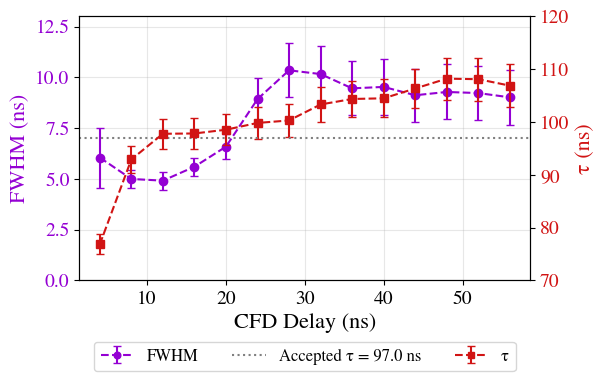

In [55]:
fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()

ax1.errorbar(df_delay['delay'], df_delay['fwhm'], yerr=df_delay['fwhm_err'],
             fmt='o--', color='#9400d3', capsize=3, lw=1.5, label='FWHM')
ax2.errorbar(df_delay['delay'], df_delay['tau'], yerr=df_delay['tau_err'],
             fmt='s--', color='#d11414', capsize=3, lw=1.5, label='τ')
ax2.axhline(97.0, color='grey', linestyle=':', lw=1.5, label='Accepted τ = 97.0 ns')

ax1.set_xlabel('CFD Delay (ns)', fontsize=16)
ax1.set_ylabel('FWHM (ns)', fontsize=16, color='#9400d3')
ax2.set_ylabel('τ (ns)', fontsize=16, color='#d11414')
ax1.tick_params(axis='y', labelcolor='#9400d3', labelsize=14)
ax2.tick_params(axis='y', labelcolor='#d11414', labelsize=14)
ax1.tick_params(axis='x', labelsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=12, markerscale=0.8,
           loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=3)

#ax1.set_title('CFD Delay Scan', fontsize=20)
ax1.set_ylim(0,13)
ax2.set_ylim(70,120)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('CFD_delay_scan')
plt.show()

  0/30554 waveforms processed...
  0/30554 waveforms processed...
thresh=-0.024 V → FWHM=6.39±0.72 ns, τ=100.49±2.49 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
thresh=-0.029 V → FWHM=6.52±0.70 ns, τ=100.25±2.49 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
thresh=-0.034 V → FWHM=6.71±0.68 ns, τ=100.09±2.49 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
thresh=-0.039 V → FWHM=6.92±0.67 ns, τ=100.39±2.51 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
thresh=-0.044 V → FWHM=7.23±0.69 ns, τ=100.67±2.53 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
thresh=-0.049 V → FWHM=7.50±0.70 ns, τ=101.15±2.56 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
thresh=-0.054 V → FWHM=7.62±0.71 ns, τ=101.71±2.65 ns
  0/30554 waveforms processed...
  0/30554 waveforms processed...
thresh=-0.059 V → FWHM=7.55±0.70 ns, τ=101.05±2.70 ns
  0/30554 waveforms processed...
  0/305

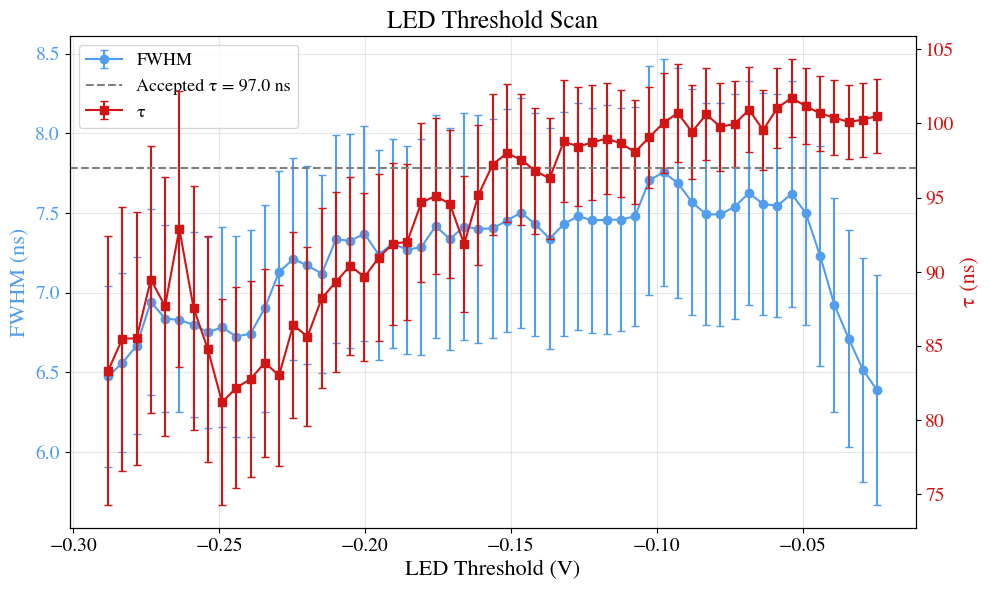

In [ ]:
thresholds = np.arange(-50, -600, -10) 
volts_per_count = 2.0 / 2**12

def expled(t, A, tau, B):
    return A * np.exp(-t / tau) + B

results_led = []

for thresh in thresholds:
    
    a_times = leading_edge_timing_linear(Pulses_corrected_alpha[both], threshold=thresh)
    g_times = leading_edge_timing_linear(Pulses_corrected[both], threshold=thresh)

    dt = (g_times - a_times) * 4
    dt_clean = dt[np.isfinite(dt)]
    dt_coinc = dt_clean[(dt_clean > -450) & (dt_clean < 550)]

    if len(dt_coinc) < 100:
        continue

    mask = (dt_coinc > -32) & (dt_coinc < 32)
    counts_g, edges_g = np.histogram(dt_coinc[mask], bins=40)
    centres_g = (edges_g[:-1] + edges_g[1:]) / 2
    B_init_g = counts_g[centres_g < -5].mean()

    try:
        popt_g, pcov_g = curve_fit(
            gaussian, centres_g, counts_g,
            p0=[counts_g.max(), 0.0, 5.0, B_init_g],
            bounds=([0, -50, 0.1, 0], [np.inf, 50, 200, np.inf]),
            maxfev=50000
        )
        fwhm = 2.355 * abs(popt_g[2])
        fwhm_err = 2.355 * np.sqrt(pcov_g[2, 2])
    except Exception as e:
        fwhm, fwhm_err = np.nan, np.nan

  
    counts_h, bin_edges_h = np.histogram(dt_coinc, bins=np.arange(-450, 554, 4))
    bin_centres_h = 0.5 * (bin_edges_h[:-1] + bin_edges_h[1:])

    B_init = counts_h[(bin_centres_h < -20) & (bin_centres_h > -400)].mean()

    fit_mask = (bin_centres_h >= 28) & (bin_centres_h <= 355) & (counts_h > 0)
    x_fit = bin_centres_h[fit_mask]
    y_fit = counts_h[fit_mask].astype(float)
    sigma = np.sqrt(np.maximum(y_fit, 1.0))

    try:
        popt, pcov = curve_fit(
            expled, x_fit, y_fit,
            p0=[y_fit.max(), 100.0, B_init],
            sigma=sigma, absolute_sigma=True,
            bounds=([0, 1e-6, 0], [np.inf, np.inf, np.inf]),
            maxfev=200000
        )
        sigma2 = np.sqrt(np.maximum(expled(x_fit, *popt), 1.0))
        popt, pcov = curve_fit(
            expled, x_fit, y_fit,
            p0=popt,
            sigma=sigma2, absolute_sigma=True,
            bounds=([0, 1e-6, 0], [np.inf, np.inf, np.inf]),
            maxfev=200000
        )
        tau = popt[1]
        tau_err = np.sqrt(pcov[1, 1])
    except Exception as e:
        tau, tau_err = np.nan, np.nan

    results_led.append({
        'threshold': thresh * volts_per_count,  
        'fwhm': fwhm, 'fwhm_err': fwhm_err,
        'tau': tau, 'tau_err': tau_err
    })
    print(f"thresh={thresh*volts_per_count:.3f} V → FWHM={fwhm:.2f}±{fwhm_err:.2f} ns, τ={tau:.2f}±{tau_err:.2f} ns")

df_led = pd.DataFrame(results_led)


fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.errorbar(df_led['threshold'], df_led['fwhm'], yerr=df_led['fwhm_err'],
             fmt='o-', color='#519DEE', capsize=3, lw=1.5, label='FWHM')
ax2.errorbar(df_led['threshold'], df_led['tau'], yerr=df_led['tau_err'],
             fmt='s-', color='#d11414', capsize=3, lw=1.5, label='τ')
ax2.axhline(97.0, color='grey', linestyle='--', lw=1.5, label='Accepted τ = 97.0 ns')

ax1.set_xlabel('LED Threshold (V)', fontsize=16)
ax1.set_ylabel('FWHM (ns)', fontsize=16, color='#519DEE')
ax2.set_ylabel('τ (ns)', fontsize=16, color='#d11414')
ax1.tick_params(axis='y', labelcolor='#519DEE', labelsize=14)
ax2.tick_params(axis='y', labelcolor='#d11414', labelsize=14)
ax1.tick_params(axis='x', labelsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=13)

ax1.set_title('LED Threshold Scan', fontsize=18)
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('LED_threshold_scan')
plt.show()

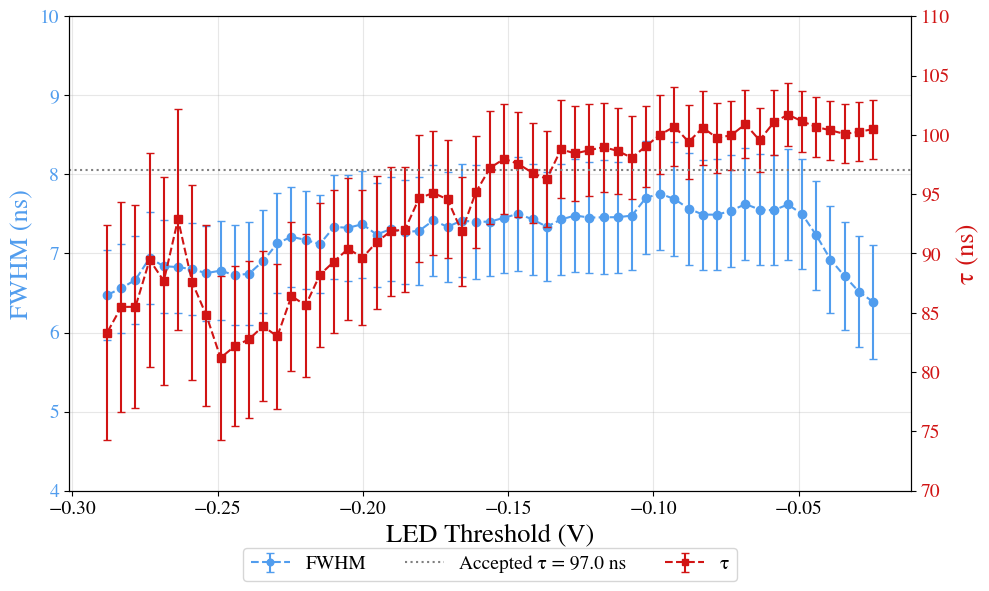

In [58]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.errorbar(df_led['threshold'], df_led['fwhm'], yerr=df_led['fwhm_err'],
             fmt='o--', color='#519DEE', capsize=3, lw=1.5, label='FWHM')
ax2.errorbar(df_led['threshold'], df_led['tau'], yerr=df_led['tau_err'],
             fmt='s--', color='#d11414', capsize=3, lw=1.5, label='τ')
ax2.axhline(97.0, color='grey', linestyle=':', lw=1.5, label='Accepted τ = 97.0 ns')

ax1.set_xlabel('LED Threshold (V)', fontsize=19)
ax1.set_ylabel('FWHM (ns)', fontsize=19, color='#519DEE')
ax2.set_ylabel('τ (ns)', fontsize=19, color='#d11414')
ax1.tick_params(axis='y', labelcolor='#519DEE', labelsize=14)
ax2.tick_params(axis='y', labelcolor='#d11414', labelsize=14)
ax1.tick_params(axis='x', labelsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=14, markerscale=0.8,
           loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)

#ax1.set_title('LED Threshold Scan', fontsize=18)
ax1.grid(alpha=0.3)
ax1.set_ylim(4,10)
ax2.set_ylim(70,110)
plt.tight_layout()
plt.savefig('LED_threshold_scan')
plt.show()

  0/40656 waveforms processed...
  0/40656 waveforms processed...
thresh=-0.024 V → N=39580
  0/40656 waveforms processed...
  0/40656 waveforms processed...
thresh=-0.029 V → N=37330
  0/40656 waveforms processed...
  0/40656 waveforms processed...
thresh=-0.034 V → N=35249
  0/40656 waveforms processed...
  0/40656 waveforms processed...
thresh=-0.039 V → N=33281
  0/40656 waveforms processed...
  0/40656 waveforms processed...
thresh=-0.044 V → N=31430
  0/40656 waveforms processed...
  0/40656 waveforms processed...
thresh=-0.049 V → N=29729
  0/40656 waveforms processed...
  0/40656 waveforms processed...
thresh=-0.054 V → N=28150
  0/40656 waveforms processed...
  0/40656 waveforms processed...
thresh=-0.059 V → N=26597
  0/40656 waveforms processed...
  0/40656 waveforms processed...
thresh=-0.063 V → N=25136
  0/40656 waveforms processed...
  0/40656 waveforms processed...
thresh=-0.068 V → N=23687
  0/40656 waveforms processed...
  0/40656 waveforms processed...
thresh=-0.073 

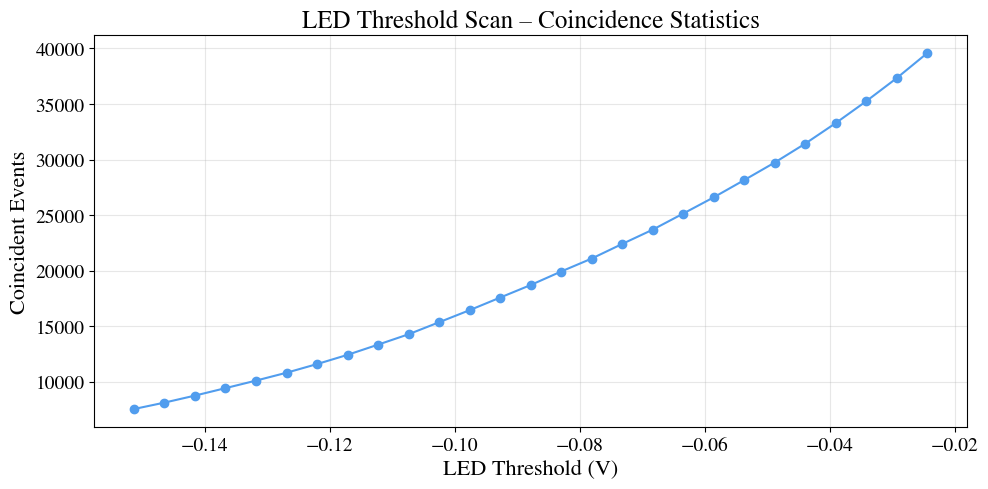

In [60]:
thresholds = np.arange(-50, -320, -10)
volts_per_count = 2.0 / 2**12

alpha_trig_scan = (Pulses_corrected_alpha.min(axis=1) < -50) & (alpha_amps_v > -1.74)
gamma_trig_scan = (Pulses_corrected.min(axis=1) < -50) & (gamma_amps_v > -1.54)
both_scan = alpha_trig_scan & gamma_trig_scan

coinc_counts = []
thresh_v = []

for thresh in thresholds:
    a_times = leading_edge_timing_linear(Pulses_corrected_alpha[both_scan], threshold=thresh)
    g_times = leading_edge_timing_linear(Pulses_corrected[both_scan], threshold=thresh)
    
    dt = (g_times - a_times) * 4
    dt_clean = dt[np.isfinite(dt)]
    dt_coinc = dt_clean[(dt_clean > -450) & (dt_clean < 550)]
    
    coinc_counts.append(len(dt_coinc))
    thresh_v.append(thresh * volts_per_count)
    print(f"thresh={thresh*volts_per_count:.3f} V → N={len(dt_coinc)}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_v, coinc_counts, 'o-', color='#519DEE', lw=1.5)
ax.set_xlabel('LED Threshold (V)', fontsize=16)
ax.set_ylabel('Coincident Events', fontsize=16)
ax.set_title('LED Threshold Scan – Coincidence Statistics', fontsize=18)
ax.tick_params(axis='both', labelsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('LED_coincidence_scan')
plt.show()

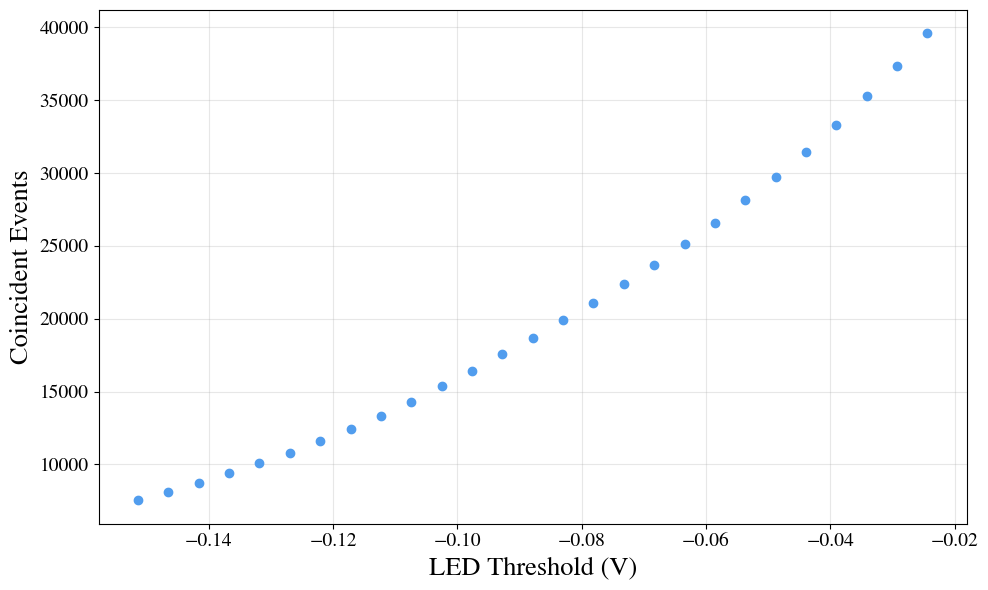

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(thresh_v, coinc_counts, 'o', color='#519DEE', lw=1.5)
ax.set_xlabel('LED Threshold (V)', fontsize=19)
ax.set_ylabel('Coincident Events', fontsize=19)
#ax.set_title('LED Threshold Scan – Coincidence Statistics', fontsize=18)
ax.tick_params(axis='both', labelsize=14)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('LED_coincidence_scan')
plt.show()